# 11 — Clustering Analysis

## Objective

This notebook applies unsupervised clustering to the latent semantic representations created in the dimensionality-reduction stage.

The analysis compares two textual representations:

- **Core LSA:** derived from book titles and authors
- **Enriched LSA:** derived from titles, authors, subjects, and available descriptions

Both representations contain 200 Truncated SVD dimensions.

Books represented by zero vectors are excluded from clustering because they contain insufficient textual information for meaningful semantic positioning. These books remain in the master catalogue and may later be handled through recommendation fallback strategies.

## Clustering Strategy

Candidate K-Means solutions will be evaluated using multiple internal validation metrics:

- Silhouette Score
- Davies–Bouldin Index
- Calinski–Harabasz Score
- Cluster-size distribution
- Semantic interpretability

No target variable is used because this is an unsupervised learning problem.

The number of clusters will not be selected from a single metric alone. Quantitative validation and semantic interpretability will be considered together.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    "/Users/jannoelvero/Documents/Ironhack/Week_11/"
    "Leadership_Management_Book_Recommendation_System"
)

PROCESSED_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)

MODELS_DIR = (
    PROJECT_DIR /
    "models"
)


print("PROJECT DIRECTORY")
print("=" * 90)

print(PROJECT_DIR)

print(
    "\nProcessed directory exists:",
    PROCESSED_DIR.exists()
)

print(
    "Models directory exists:",
    MODELS_DIR.exists()
)

PROJECT DIRECTORY
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System

Processed directory exists: True
Models directory exists: True


In [2]:
# ============================================================
# LOAD LSA REPRESENTATIONS
# ============================================================

core_lsa = pd.read_csv(
    PROCESSED_DIR /
    "core_lsa_200.csv"
)

enriched_lsa = pd.read_csv(
    PROCESSED_DIR /
    "enriched_lsa_200.csv"
)


print("LSA DATA LOADED")
print("=" * 90)

print(
    "Core:",
    core_lsa.shape
)

print(
    "Enriched:",
    enriched_lsa.shape
)


display(
    core_lsa.head()
)

LSA DATA LOADED
Core: (2067, 202)
Enriched: (2067, 202)


,book_id,is_zero_vector,LSA_1,LSA_2,LSA_3,LSA_4,LSA_5,LSA_6,LSA_7,LSA_8,...,LSA_191,LSA_192,LSA_193,LSA_194,LSA_195,LSA_196,LSA_197,LSA_198,LSA_199,LSA_200
0,BOOK00001,False,0.195129,-0.102799,-0.009352,0.011361,0.011709,-0.024553,-0.028008,-0.001652,...,0.046454,-0.067724,-0.000009,-0.044899,-0.015334,-0.019201,0.012374,0.008622,0.068729,-0.074647
1,BOOK00002,False,0.175160,-0.063761,-0.002240,0.063209,-0.018299,-0.024757,-0.020393,0.016207,...,0.040092,0.050667,0.008939,-0.011021,-0.000608,-0.041077,0.046348,-0.028491,0.014144,0.021192
2,BOOK00003,True,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,BOOK00004,False,0.293401,-0.161017,-0.015467,0.005948,-0.020776,-0.025938,-0.033152,-0.005775,...,0.011642,-0.069681,-0.071459,0.012157,0.008127,0.013492,0.005973,-0.008989,0.038746,0.017140
4,BOOK00005,False,0.158955,-0.070796,-0.000177,0.003436,-0.003543,-0.002387,-0.021629,0.023369,...,0.012848,-0.052263,-0.028180,-0.029160,-0.032568,0.020136,0.058351,-0.018743,0.005317,0.029888


In [3]:
# ============================================================
# LSA VALIDATION
# ============================================================

assert len(core_lsa) == 2067
assert len(enriched_lsa) == 2067

assert (
    core_lsa["book_id"].values
    == enriched_lsa["book_id"].values
).all()

assert (
    core_lsa["book_id"].nunique()
    == 2067
)

assert (
    enriched_lsa["book_id"].nunique()
    == 2067
)


print("LSA VALIDATION")
print("=" * 90)

print(
    "Core zero vectors:",
    core_lsa["is_zero_vector"].sum()
)

print(
    "Enriched zero vectors:",
    enriched_lsa["is_zero_vector"].sum()
)

print(
    "\nCore usable books:",
    (~core_lsa["is_zero_vector"]).sum()
)

print(
    "Enriched usable books:",
    (~enriched_lsa["is_zero_vector"]).sum()
)


print(
    "\n✓ Book IDs align across representations."
)

print(
    "✓ No duplicate book IDs."
)

LSA VALIDATION
Core zero vectors: 42
Enriched zero vectors: 27

Core usable books: 2025
Enriched usable books: 2040

✓ Book IDs align across representations.
✓ No duplicate book IDs.


In [4]:
# ============================================================
# CREATE CLUSTERING DATASETS
# ============================================================

lsa_columns = [
    f"LSA_{i}"
    for i in range(
        1,
        201
    )
]


core_cluster_books = (
    core_lsa.loc[
        ~core_lsa["is_zero_vector"]
    ]
    .copy()
    .reset_index(drop=True)
)


enriched_cluster_books = (
    enriched_lsa.loc[
        ~enriched_lsa["is_zero_vector"]
    ]
    .copy()
    .reset_index(drop=True)
)


X_core = core_cluster_books[
    lsa_columns
].to_numpy()


X_enriched = enriched_cluster_books[
    lsa_columns
].to_numpy()


print("CLUSTERING MATRICES")
print("=" * 90)

print(
    "Core:",
    X_core.shape
)

print(
    "Enriched:",
    X_enriched.shape
)


assert X_core.shape == (
    2025,
    200
)

assert X_enriched.shape == (
    2040,
    200
)

assert np.isfinite(
    X_core
).all()

assert np.isfinite(
    X_enriched
).all()


print(
    "\n✓ Core clustering matrix validated."
)

print(
    "✓ Enriched clustering matrix validated."
)

CLUSTERING MATRICES
Core: (2025, 200)
Enriched: (2040, 200)

✓ Core clustering matrix validated.
✓ Enriched clustering matrix validated.


In [5]:
# ============================================================
# CREATE CLUSTERING DATASETS
# ============================================================

lsa_columns = [
    f"LSA_{i}"
    for i in range(
        1,
        201
    )
]


core_cluster_books = (
    core_lsa.loc[
        ~core_lsa["is_zero_vector"]
    ]
    .copy()
    .reset_index(drop=True)
)


enriched_cluster_books = (
    enriched_lsa.loc[
        ~enriched_lsa["is_zero_vector"]
    ]
    .copy()
    .reset_index(drop=True)
)


X_core = core_cluster_books[
    lsa_columns
].to_numpy()


X_enriched = enriched_cluster_books[
    lsa_columns
].to_numpy()


print("CLUSTERING MATRICES")
print("=" * 90)

print(
    "Core:",
    X_core.shape
)

print(
    "Enriched:",
    X_enriched.shape
)


assert X_core.shape == (
    2025,
    200
)

assert X_enriched.shape == (
    2040,
    200
)

assert np.isfinite(
    X_core
).all()

assert np.isfinite(
    X_enriched
).all()


print(
    "\n✓ Core clustering matrix validated."
)

print(
    "✓ Enriched clustering matrix validated."
)

CLUSTERING MATRICES
Core: (2025, 200)
Enriched: (2040, 200)

✓ Core clustering matrix validated.
✓ Enriched clustering matrix validated.


In [6]:
# ============================================================
# K-MEANS CANDIDATE EVALUATION FUNCTION
# ============================================================

def evaluate_kmeans_candidates(
    X,
    representation,
    k_values=range(2, 16),
    random_state=42
):

    results = []

    for k in k_values:

        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20
        )

        labels = model.fit_predict(X)

        results.append({
            "representation": representation,
            "k": k,
            "silhouette_score":
                silhouette_score(
                    X,
                    labels
                ),
            "davies_bouldin_score":
                davies_bouldin_score(
                    X,
                    labels
                ),
            "calinski_harabasz_score":
                calinski_harabasz_score(
                    X,
                    labels
                ),
            "inertia":
                model.inertia_,
            "smallest_cluster":
                np.bincount(labels).min(),
            "largest_cluster":
                np.bincount(labels).max()
        })

        print(
            f"{representation} | "
            f"k={k:2d} completed"
        )

    return pd.DataFrame(results)

In [7]:
# ============================================================
# CORE LSA — K-MEANS EVALUATION
# ============================================================

core_kmeans_results = (
    evaluate_kmeans_candidates(
        X=X_core,
        representation="Core",
        k_values=range(2, 16),
        random_state=42
    )
)


print(
    "\nCORE LSA — K-MEANS RESULTS"
)

print(
    "=" * 100
)


display(
    core_kmeans_results.round({
        "silhouette_score": 4,
        "davies_bouldin_score": 4,
        "calinski_harabasz_score": 2,
        "inertia": 2
    })
)

Core | k= 2 completed
Core | k= 3 completed
Core | k= 4 completed
Core | k= 5 completed
Core | k= 6 completed
Core | k= 7 completed
Core | k= 8 completed
Core | k= 9 completed
Core | k=10 completed
Core | k=11 completed
Core | k=12 completed
Core | k=13 completed
Core | k=14 completed
Core | k=15 completed

CORE LSA — K-MEANS RESULTS


,representation,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia,smallest_cluster,largest_cluster
0,Core,2,0.0414,4.2370,49.33,968.85,281,1744
1,Core,3,0.0471,3.5961,39.34,955.30,49,1695
2,Core,4,0.0670,2.0166,35.01,943.44,48,1878
3,Core,5,0.0538,3.5761,38.33,922.47,38,1380
4,Core,6,0.0586,2.7540,33.71,916.01,35,1608
5,Core,7,0.0528,3.0828,34.01,901.34,38,1385
6,Core,8,0.0563,2.3316,30.73,896.83,40,1698
7,Core,9,0.0625,2.5396,31.35,882.68,15,1520
8,Core,10,0.0737,2.1947,34.21,860.93,38,1589
9,Core,11,0.0766,2.3237,31.11,859.67,23,1599


In [8]:
# ============================================================
# ENRICHED LSA — K-MEANS EVALUATION
# ============================================================

enriched_kmeans_results = (
    evaluate_kmeans_candidates(
        X=X_enriched,
        representation="Enriched",
        k_values=range(2, 16),
        random_state=42
    )
)


print(
    "\nENRICHED LSA — K-MEANS RESULTS"
)

print(
    "=" * 100
)


display(
    enriched_kmeans_results.round({
        "silhouette_score": 4,
        "davies_bouldin_score": 4,
        "calinski_harabasz_score": 2,
        "inertia": 2
    })
)

Enriched | k= 2 completed
Enriched | k= 3 completed
Enriched | k= 4 completed
Enriched | k= 5 completed
Enriched | k= 6 completed
Enriched | k= 7 completed
Enriched | k= 8 completed
Enriched | k= 9 completed
Enriched | k=10 completed
Enriched | k=11 completed
Enriched | k=12 completed
Enriched | k=13 completed
Enriched | k=14 completed
Enriched | k=15 completed

ENRICHED LSA — K-MEANS RESULTS


,representation,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia,smallest_cluster,largest_cluster
0,Enriched,2,0.0412,5.2344,51.93,826.61,498,1542
1,Enriched,3,0.0400,4.9061,46.88,810.37,264,1285
2,Enriched,4,0.0477,3.7957,39.89,800.61,47,1474
3,Enriched,5,0.0508,3.8124,39.58,786.48,84,1314
4,Enriched,6,0.0577,3.2740,36.33,778.17,28,1372
5,Enriched,7,0.0578,3.0816,31.72,775.12,11,1361
6,Enriched,8,0.0676,2.8155,34.51,757.60,10,1416
7,Enriched,9,0.0664,2.7814,31.79,753.35,6,1368
8,Enriched,10,0.0681,2.5264,30.38,747.06,15,1441
9,Enriched,11,0.0734,2.5570,30.53,736.80,6,1364


In [9]:
# ============================================================
# CORE VS ENRICHED COMPARISON
# ============================================================

kmeans_comparison = pd.concat(
    [
        core_kmeans_results,
        enriched_kmeans_results
    ],
    ignore_index=True
)


comparison_table = (
    kmeans_comparison[
        [
            "representation",
            "k",
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score",
            "smallest_cluster",
            "largest_cluster"
        ]
    ]
    .copy()
)


comparison_table[
    "largest_cluster_pct"
] = np.where(
    comparison_table[
        "representation"
    ].eq("Core"),
    comparison_table[
        "largest_cluster"
    ] / len(X_core) * 100,
    comparison_table[
        "largest_cluster"
    ] / len(X_enriched) * 100
)


display(
    comparison_table.round({
        "silhouette_score": 4,
        "davies_bouldin_score": 4,
        "calinski_harabasz_score": 2,
        "largest_cluster_pct": 2
    })
)

,representation,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster,largest_cluster,largest_cluster_pct
0,Core,2,0.0414,4.2370,49.33,281,1744,86.12
1,Core,3,0.0471,3.5961,39.34,49,1695,83.70
2,Core,4,0.0670,2.0166,35.01,48,1878,92.74
3,Core,5,0.0538,3.5761,38.33,38,1380,68.15
4,Core,6,0.0586,2.7540,33.71,35,1608,79.41
5,Core,7,0.0528,3.0828,34.01,38,1385,68.40
6,Core,8,0.0563,2.3316,30.73,40,1698,83.85
7,Core,9,0.0625,2.5396,31.35,15,1520,75.06
8,Core,10,0.0737,2.1947,34.21,38,1589,78.47
9,Core,11,0.0766,2.3237,31.11,23,1599,78.96


In [10]:
# ============================================================
# L2-NORMALIZE LSA REPRESENTATIONS
# ============================================================

from sklearn.preprocessing import normalize


X_core_norm = normalize(
    X_core,
    norm="l2"
)

X_enriched_norm = normalize(
    X_enriched,
    norm="l2"
)


print("L2-NORMALIZED LSA MATRICES")
print("=" * 90)

print(
    "Core:",
    X_core_norm.shape
)

print(
    "Enriched:",
    X_enriched_norm.shape
)


# ------------------------------------------------------------
# Validate row norms
# ------------------------------------------------------------

core_norms = np.linalg.norm(
    X_core_norm,
    axis=1
)

enriched_norms = np.linalg.norm(
    X_enriched_norm,
    axis=1
)


print(
    "\nCore norm range:",
    core_norms.min(),
    "to",
    core_norms.max()
)

print(
    "Enriched norm range:",
    enriched_norms.min(),
    "to",
    enriched_norms.max()
)


assert np.allclose(
    core_norms,
    1.0
)

assert np.allclose(
    enriched_norms,
    1.0
)


print(
    "\n✓ All clusterable Core vectors have unit norm."
)

print(
    "✓ All clusterable Enriched vectors have unit norm."
)

L2-NORMALIZED LSA MATRICES
Core: (2025, 200)
Enriched: (2040, 200)

Core norm range: 0.9999999999999989 to 1.000000000000001
Enriched norm range: 0.9999999999999989 to 1.0000000000000013

✓ All clusterable Core vectors have unit norm.
✓ All clusterable Enriched vectors have unit norm.


In [11]:
# ============================================================
# NORMALIZED LSA — K-MEANS EVALUATION
# ============================================================

core_norm_results = (
    evaluate_kmeans_candidates(
        X=X_core_norm,
        representation="Core_Normalized",
        k_values=range(2, 16),
        random_state=42
    )
)


enriched_norm_results = (
    evaluate_kmeans_candidates(
        X=X_enriched_norm,
        representation="Enriched_Normalized",
        k_values=range(2, 16),
        random_state=42
    )
)


print(
    "\nCORE — NORMALIZED"
)

display(
    core_norm_results.round({
        "silhouette_score": 4,
        "davies_bouldin_score": 4,
        "calinski_harabasz_score": 2,
        "inertia": 2
    })
)


print(
    "\nENRICHED — NORMALIZED"
)

display(
    enriched_norm_results.round({
        "silhouette_score": 4,
        "davies_bouldin_score": 4,
        "calinski_harabasz_score": 2,
        "inertia": 2
    })
)

Core_Normalized | k= 2 completed
Core_Normalized | k= 3 completed
Core_Normalized | k= 4 completed
Core_Normalized | k= 5 completed
Core_Normalized | k= 6 completed
Core_Normalized | k= 7 completed
Core_Normalized | k= 8 completed
Core_Normalized | k= 9 completed
Core_Normalized | k=10 completed
Core_Normalized | k=11 completed
Core_Normalized | k=12 completed
Core_Normalized | k=13 completed
Core_Normalized | k=14 completed
Core_Normalized | k=15 completed
Enriched_Normalized | k= 2 completed
Enriched_Normalized | k= 3 completed
Enriched_Normalized | k= 4 completed
Enriched_Normalized | k= 5 completed
Enriched_Normalized | k= 6 completed
Enriched_Normalized | k= 7 completed
Enriched_Normalized | k= 8 completed
Enriched_Normalized | k= 9 completed
Enriched_Normalized | k=10 completed
Enriched_Normalized | k=11 completed
Enriched_Normalized | k=12 completed
Enriched_Normalized | k=13 completed
Enriched_Normalized | k=14 completed
Enriched_Normalized | k=15 completed

CORE — NORMALIZED


,representation,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia,smallest_cluster,largest_cluster
0,Core_Normalized,2,0.0188,4.4069,47.76,1946.38,290,1735
1,Core_Normalized,3,0.0276,5.1027,43.94,1909.35,287,1362
2,Core_Normalized,4,0.0377,4.2934,41.42,1876.94,49,1313
3,Core_Normalized,5,0.0401,3.7629,38.98,1849.56,49,1317
4,Core_Normalized,6,0.0455,3.5682,36.71,1826.31,49,1249
5,Core_Normalized,7,0.0436,3.3851,34.06,1809.13,38,1260
6,Core_Normalized,8,0.0561,3.3046,33.01,1787.56,45,1219
7,Core_Normalized,9,0.0585,3.2871,33.11,1760.96,49,1156
8,Core_Normalized,10,0.0617,4.5384,31.21,1748.60,40,728
9,Core_Normalized,11,0.0687,3.2583,31.44,1723.28,40,1098



ENRICHED — NORMALIZED


,representation,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia,smallest_cluster,largest_cluster
0,Enriched_Normalized,2,0.0179,5.6181,48.26,1949.10,531,1509
1,Enriched_Normalized,3,0.0250,5.2806,44.28,1912.12,284,1235
2,Enriched_Normalized,4,0.0332,4.4433,41.30,1880.81,51,1188
3,Enriched_Normalized,5,0.0331,4.1564,38.38,1855.29,51,1192
4,Enriched_Normalized,6,0.0366,3.8472,36.21,1832.17,51,1203
5,Enriched_Normalized,7,0.0422,3.6187,34.04,1813.10,51,1189
6,Enriched_Normalized,8,0.0464,3.5350,33.10,1791.01,51,1134
7,Enriched_Normalized,9,0.0518,3.2769,31.97,1772.08,48,1199
8,Enriched_Normalized,10,0.0532,3.1293,31.35,1751.79,44,1195
9,Enriched_Normalized,11,0.0527,3.5128,29.04,1745.43,43,1044


In [12]:
# ============================================================
# AGGLOMERATIVE CLUSTERING — ENRICHED NORMALIZED LSA
# ============================================================

from sklearn.cluster import AgglomerativeClustering


def evaluate_agglomerative_candidates(
    X,
    k_values=range(2, 16)
):

    results = []

    for k in k_values:

        model = AgglomerativeClustering(
            n_clusters=k,
            metric="cosine",
            linkage="average"
        )

        labels = model.fit_predict(X)

        cluster_sizes = np.bincount(
            labels
        )

        results.append({
            "k": k,

            # Cosine is appropriate for normalized
            # semantic vectors
            "silhouette_cosine":
                silhouette_score(
                    X,
                    labels,
                    metric="cosine"
                ),

            # DB and CH are Euclidean-based diagnostics.
            # Retained as secondary comparison metrics.
            "davies_bouldin":
                davies_bouldin_score(
                    X,
                    labels
                ),

            "calinski_harabasz":
                calinski_harabasz_score(
                    X,
                    labels
                ),

            "smallest_cluster":
                cluster_sizes.min(),

            "largest_cluster":
                cluster_sizes.max(),

            "largest_cluster_pct":
                cluster_sizes.max()
                / len(X)
                * 100
        })

        print(
            f"Agglomerative | "
            f"k={k:2d} completed"
        )

    return pd.DataFrame(
        results
    )

In [13]:
# ============================================================
# EVALUATE AGGLOMERATIVE SOLUTIONS
# ============================================================

agglomerative_results = (
    evaluate_agglomerative_candidates(
        X_enriched_norm,
        k_values=range(2, 16)
    )
)


print(
    "\nAGGLOMERATIVE CLUSTERING RESULTS"
)

print(
    "=" * 100
)


display(
    agglomerative_results.round({
        "silhouette_cosine": 4,
        "davies_bouldin": 4,
        "calinski_harabasz": 2,
        "largest_cluster_pct": 2
    })
)

Agglomerative | k= 2 completed
Agglomerative | k= 3 completed
Agglomerative | k= 4 completed
Agglomerative | k= 5 completed
Agglomerative | k= 6 completed
Agglomerative | k= 7 completed
Agglomerative | k= 8 completed
Agglomerative | k= 9 completed
Agglomerative | k=10 completed
Agglomerative | k=11 completed
Agglomerative | k=12 completed
Agglomerative | k=13 completed
Agglomerative | k=14 completed
Agglomerative | k=15 completed

AGGLOMERATIVE CLUSTERING RESULTS


,k,silhouette_cosine,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster,largest_cluster_pct
0,2,0.0234,2.3262,9.47,18,2022,99.12
1,3,0.0219,4.6549,8.61,18,1952,95.69
2,4,0.0226,5.4262,8.57,18,1847,90.54
3,5,0.0245,5.5599,8.89,18,1741,85.34
4,6,0.0260,5.6704,8.85,18,1642,80.49
5,7,0.0261,5.2101,8.55,18,1642,80.49
6,8,0.0287,5.2063,8.85,18,1554,76.18
7,9,0.0295,4.9849,8.69,18,1554,76.18
8,10,0.0323,5.0210,8.94,18,1453,71.23
9,11,0.0328,4.8059,8.71,15,1438,70.49


In [14]:
# ============================================================
# K-MEANS — COSINE-BASED SEMANTIC EVALUATION
# ============================================================

def evaluate_kmeans_cosine(
    X,
    representation,
    k_values=range(2, 16),
    random_state=42
):

    results = []

    for k in k_values:

        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20
        )

        labels = model.fit_predict(
            X
        )

        cluster_sizes = np.bincount(
            labels
        )

        results.append({
            "representation":
                representation,

            "k":
                k,

            "silhouette_cosine":
                silhouette_score(
                    X,
                    labels,
                    metric="cosine"
                ),

            "smallest_cluster":
                cluster_sizes.min(),

            "largest_cluster":
                cluster_sizes.max(),

            "largest_cluster_pct":
                cluster_sizes.max()
                / len(X)
                * 100
        })

    return pd.DataFrame(
        results
    )

In [15]:
# ============================================================
# CORE AND ENRICHED — COSINE SILHOUETTE
# ============================================================

core_cosine_results = (
    evaluate_kmeans_cosine(
        X_core_norm,
        "Core_Normalized",
        range(2, 16)
    )
)


enriched_cosine_results = (
    evaluate_kmeans_cosine(
        X_enriched_norm,
        "Enriched_Normalized",
        range(2, 16)
    )
)


print(
    "CORE NORMALIZED — COSINE EVALUATION"
)

print(
    "=" * 90
)

display(
    core_cosine_results.round({
        "silhouette_cosine": 4,
        "largest_cluster_pct": 2
    })
)


print(
    "\nENRICHED NORMALIZED — COSINE EVALUATION"
)

print(
    "=" * 90
)

display(
    enriched_cosine_results.round({
        "silhouette_cosine": 4,
        "largest_cluster_pct": 2
    })
)

CORE NORMALIZED — COSINE EVALUATION


,representation,k,silhouette_cosine,smallest_cluster,largest_cluster,largest_cluster_pct
0,Core_Normalized,2,0.0323,290,1735,85.68
1,Core_Normalized,3,0.0475,287,1362,67.26
2,Core_Normalized,4,0.0620,49,1313,64.84
3,Core_Normalized,5,0.0631,49,1317,65.04
4,Core_Normalized,6,0.0722,49,1249,61.68
5,Core_Normalized,7,0.0657,38,1260,62.22
6,Core_Normalized,8,0.0880,45,1219,60.20
7,Core_Normalized,9,0.0904,49,1156,57.09
8,Core_Normalized,10,0.0942,40,728,35.95
9,Core_Normalized,11,0.1059,40,1098,54.22



ENRICHED NORMALIZED — COSINE EVALUATION


,representation,k,silhouette_cosine,smallest_cluster,largest_cluster,largest_cluster_pct
0,Enriched_Normalized,2,0.0314,531,1509,73.97
1,Enriched_Normalized,3,0.0442,284,1235,60.54
2,Enriched_Normalized,4,0.0561,51,1188,58.24
3,Enriched_Normalized,5,0.0545,51,1192,58.43
4,Enriched_Normalized,6,0.0597,51,1203,58.97
5,Enriched_Normalized,7,0.0682,51,1189,58.28
6,Enriched_Normalized,8,0.0758,51,1134,55.59
7,Enriched_Normalized,9,0.0848,48,1199,58.77
8,Enriched_Normalized,10,0.0860,44,1195,58.58
9,Enriched_Normalized,11,0.0847,43,1044,51.18


In [16]:
# ============================================================
# K-MEANS VS AGGLOMERATIVE — ENRICHED COSINE COMPARISON
# ============================================================

kmeans_compare = (
    enriched_cosine_results[
        [
            "k",
            "silhouette_cosine",
            "smallest_cluster",
            "largest_cluster",
            "largest_cluster_pct"
        ]
    ]
    .copy()
)

kmeans_compare[
    "method"
] = "KMeans"


agg_compare = (
    agglomerative_results[
        [
            "k",
            "silhouette_cosine",
            "smallest_cluster",
            "largest_cluster",
            "largest_cluster_pct"
        ]
    ]
    .copy()
)

agg_compare[
    "method"
] = "Agglomerative"


method_comparison = pd.concat(
    [
        kmeans_compare,
        agg_compare
    ],
    ignore_index=True
)


method_comparison = (
    method_comparison[
        [
            "method",
            "k",
            "silhouette_cosine",
            "smallest_cluster",
            "largest_cluster",
            "largest_cluster_pct"
        ]
    ]
    .sort_values(
        [
            "k",
            "method"
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    method_comparison.round({
        "silhouette_cosine": 4,
        "largest_cluster_pct": 2
    })
)

,method,k,silhouette_cosine,smallest_cluster,largest_cluster,largest_cluster_pct
0,Agglomerative,2,0.0234,18,2022,99.12
1,KMeans,2,0.0314,531,1509,73.97
2,Agglomerative,3,0.0219,18,1952,95.69
3,KMeans,3,0.0442,284,1235,60.54
4,Agglomerative,4,0.0226,18,1847,90.54
5,KMeans,4,0.0561,51,1188,58.24
6,Agglomerative,5,0.0245,18,1741,85.34
7,KMeans,5,0.0545,51,1192,58.43
8,Agglomerative,6,0.0260,18,1642,80.49
9,KMeans,6,0.0597,51,1203,58.97


In [17]:
# ============================================================
# EXTENDED K SEARCH — ENRICHED NORMALIZED LSA
# ============================================================

enriched_cosine_extended = (
    evaluate_kmeans_cosine(
        X=X_enriched_norm,
        representation="Enriched_Normalized",
        k_values=range(16, 31),
        random_state=42
    )
)


enriched_cosine_full = pd.concat(
    [
        enriched_cosine_results,
        enriched_cosine_extended
    ],
    ignore_index=True
)


print(
    "ENRICHED NORMALIZED — EXTENDED COSINE EVALUATION"
)

print(
    "=" * 100
)


display(
    enriched_cosine_full.round({
        "silhouette_cosine": 4,
        "largest_cluster_pct": 2
    })
)

ENRICHED NORMALIZED — EXTENDED COSINE EVALUATION


,representation,k,silhouette_cosine,smallest_cluster,largest_cluster,largest_cluster_pct
0,Enriched_Normalized,2,0.0314,531,1509,73.97
1,Enriched_Normalized,3,0.0442,284,1235,60.54
2,Enriched_Normalized,4,0.0561,51,1188,58.24
3,Enriched_Normalized,5,0.0545,51,1192,58.43
4,Enriched_Normalized,6,0.0597,51,1203,58.97
5,Enriched_Normalized,7,0.0682,51,1189,58.28
6,Enriched_Normalized,8,0.0758,51,1134,55.59
7,Enriched_Normalized,9,0.0848,48,1199,58.77
8,Enriched_Normalized,10,0.0860,44,1195,58.58
9,Enriched_Normalized,11,0.0847,43,1044,51.18


In [18]:
# ============================================================
# EXTENDED CLUSTER-BALANCE DIAGNOSTICS
# ============================================================

balance_results = []


for k in range(2, 31):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_enriched_norm
    )

    sizes = np.bincount(
        labels
    )


    balance_results.append({
        "k":
            k,

        "smallest_cluster":
            sizes.min(),

        "median_cluster":
            np.median(sizes),

        "largest_cluster":
            sizes.max(),

        "largest_cluster_pct":
            sizes.max()
            / len(X_enriched_norm)
            * 100,

        "clusters_under_20":
            (sizes < 20).sum(),

        "clusters_under_10":
            (sizes < 10).sum()
    })


balance_results = pd.DataFrame(
    balance_results
)


extended_evaluation = (
    enriched_cosine_full.merge(
        balance_results,
        on="k",
        how="left",
        suffixes=("", "_balance")
    )
)


display(
    extended_evaluation[
        [
            "k",
            "silhouette_cosine",
            "smallest_cluster_balance",
            "median_cluster",
            "largest_cluster_balance",
            "largest_cluster_pct_balance",
            "clusters_under_20",
            "clusters_under_10"
        ]
    ].round({
        "silhouette_cosine": 4,
        "median_cluster": 1,
        "largest_cluster_pct_balance": 2
    })
)

,k,silhouette_cosine,smallest_cluster_balance,median_cluster,largest_cluster_balance,largest_cluster_pct_balance,clusters_under_20,clusters_under_10
0,2,0.0314,531,1020.0,1509,73.97,0,0
1,3,0.0442,284,521.0,1235,60.54,0,0
2,4,0.0561,51,400.5,1188,58.24,0,0
3,5,0.0545,51,283.0,1192,58.43,0,0
4,6,0.0597,51,210.0,1203,58.97,0,0
5,7,0.0682,51,115.0,1189,58.28,0,0
6,8,0.0758,51,87.5,1134,55.59,0,0
7,9,0.0848,48,84.0,1199,58.77,0,0
8,10,0.0860,44,66.0,1195,58.58,0,0
9,11,0.0847,43,89.0,1044,51.18,0,0


In [19]:
# ============================================================
# FIT CANDIDATE CLUSTERING SOLUTIONS
# ============================================================

candidate_k_values = [
    20,
    24,
    29
]


candidate_models = {}
candidate_labels = {}


for k in candidate_k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_enriched_norm
    )

    candidate_models[k] = model
    candidate_labels[k] = labels


print("CANDIDATE MODELS FITTED")
print("=" * 90)


for k in candidate_k_values:

    sizes = np.bincount(
        candidate_labels[k]
    )

    print(
        f"k={k:2d} | "
        f"smallest={sizes.min():3d} | "
        f"median={np.median(sizes):5.1f} | "
        f"largest={sizes.max():3d}"
    )

CANDIDATE MODELS FITTED
k=20 | smallest= 31 | median= 50.0 | largest=749
k=24 | smallest= 25 | median= 51.0 | largest=610
k=29 | smallest= 20 | median= 47.0 | largest=455


In [20]:
# ============================================================
# LOAD BOOK METADATA FOR CLUSTER INTERPRETATION
# ============================================================

book_features = pd.read_csv(
    PROCESSED_DIR /
    "books_features.csv"
)


print(
    "Book features:",
    book_features.shape
)


print(
    "Unique book IDs:",
    book_features["book_id"].nunique()
)


metadata_columns = [
    "book_id",
    "canonical_title",
    "authors_text"
]


cluster_metadata = (
    enriched_cluster_books[
        ["book_id"]
    ]
    .merge(
        book_features[
            metadata_columns
        ],
        on="book_id",
        how="left",
        validate="one_to_one"
    )
)


assert len(
    cluster_metadata
) == len(
    X_enriched_norm
)


assert (
    cluster_metadata[
        "canonical_title"
    ]
    .notna()
    .all()
)


print(
    "\nCluster metadata:",
    cluster_metadata.shape
)

print(
    "Missing titles:",
    cluster_metadata[
        "canonical_title"
    ].isna().sum()
)


display(
    cluster_metadata.head()
)

Book features: (2067, 69)
Unique book IDs: 2067

Cluster metadata: (2040, 3)
Missing titles: 0


,book_id,canonical_title,authors_text
0,BOOK00001,Principle-Centered Leadership,Stephen R. Covey
1,BOOK00002,Leadership in Organizations,Gary A. Yukl
2,BOOK00003,Kepemimpinan =,Karjadi M.
3,BOOK00004,Spiritual leadership,J. Oswald Sanders
4,BOOK00005,Leadership,Peter Guy Northouse


In [21]:
# ============================================================
# REPRESENTATIVE BOOKS — k=29
# ============================================================

k = 29

model = candidate_models[k]

labels = candidate_labels[k]


distances = model.transform(
    X_enriched_norm
)


representative_rows = []


for cluster_id in range(k):

    member_indices = np.where(
        labels == cluster_id
    )[0]

    member_distances = distances[
        member_indices,
        cluster_id
    ]

    closest_indices = member_indices[
        np.argsort(
            member_distances
        )[:5]
    ]


    for rank, idx in enumerate(
        closest_indices,
        start=1
    ):

        representative_rows.append({
            "cluster":
                cluster_id,

            "cluster_size":
                len(member_indices),

            "rank":
                rank,

            "book_id":
                cluster_metadata.loc[
                    idx,
                    "book_id"
                ],

            "title":
                cluster_metadata.loc[
                    idx,
                    "canonical_title"
                ],

            "authors":
                cluster_metadata.loc[
                    idx,
                    "authors_text"
                ],

            "distance_to_centroid":
                distances[
                    idx,
                    cluster_id
                ]
        })


representative_books_29 = pd.DataFrame(
    representative_rows
)


display(
    representative_books_29
)

,cluster,cluster_size,rank,book_id,title,authors,distance_to_centroid
0,0,47,1,BOOK00605,Performance Management for Dummies,Dummies Staff Herman Aguinis,0.496095
1,0,47,2,BOOK00569,Performance management systems,Arup Varma,0.519037
2,0,47,3,BOOK00606,Performance Management (Acca),Kaplan Publishing,0.574372
3,0,47,4,BOOK00579,Performance management,Ralph R Smith,0.587042
4,0,47,5,BOOK00573,Managing performance,Michael Armstrong Angela Baron,0.607148
...,...,...,...,...,...,...,...
140,28,20,1,BOOK01973,Get Scalable,Ryan Deiss,0.287401
141,28,20,2,BOOK01565,Blindspots,Ryan Sorley,0.287401
142,28,20,3,BOOK01818,How to Untie a Balloon,Ryan Dunlap,0.347195
143,28,20,4,BOOK01202,ThinkBlink Manifesto,Ryan Dunlap,0.347195


In [25]:
# ============================================================
# k=29 — COMPACT REPRESENTATIVE BOOK SUMMARY
# CORRECTED FOR MISSING AUTHOR VALUES
# ============================================================

representative_books_display = (
    representative_books_29.copy()
)


# Display-only handling of missing metadata
representative_books_display[
    "title"
] = (
    representative_books_display[
        "title"
    ]
    .fillna("Unknown")
    .astype(str)
)


representative_books_display[
    "authors"
] = (
    representative_books_display[
        "authors"
    ]
    .fillna("Unknown")
    .astype(str)
)


cluster_book_summary_29 = (
    representative_books_display
    .groupby(
        [
            "cluster",
            "cluster_size"
        ],
        as_index=False
    )
    .agg(
        representative_titles=(
            "title",
            lambda x:
                " | ".join(
                    x.tolist()
                )
        ),

        representative_authors=(
            "authors",
            lambda x:
                " | ".join(
                    x.tolist()
                )
        )
    )
)


print(
    "CLUSTER BOOK SUMMARY"
)

print(
    "=" * 90
)

print(
    "Clusters:",
    len(cluster_book_summary_29)
)


assert (
    len(cluster_book_summary_29)
    == 29
)


display(
    cluster_book_summary_29
)

CLUSTER BOOK SUMMARY
Clusters: 29


,cluster,cluster_size,representative_titles,representative_authors
0,0,47,Performance Management for Dummies | Performan...,Dummies Staff Herman Aguinis | Arup Varma | Ka...
1,1,42,Servant Leadership | Servant Leadership Roadma...,Pastor Cecil Hollaway | Cara H Bramlett | Math...
2,2,54,Project Management in Perspective | Contempora...,Theuns Oosthuizen | Timothy Kloppenborg Kathry...
3,3,455,Leaders Eat Last | Tribal leadership | Uniting...,Simon Sinek | David Logan Dave Logan John King...
4,4,127,Kepemimpinan = | The Soil of Leadership | Flow...,Karjadi M. | Britt Yamamoto | Gaelle Devins | ...
5,5,51,Emotional Intelligence : How to Improve Emotio...,Kati Haylock | Tanvir Shakil | Emotional Pathw...
6,6,82,Strategic management | Strategic management | ...,"Samuel C. Certo J.Paul Peter | Pearce, John A...."
7,7,40,Executive leadership | Executive Leadership Co...,Edutext. | The Executive Leadership Council Th...
8,8,32,Ice Cold Leader | Reinventing the Leader | The...,Errol Doebler | Gui Loureiro and Carlos E. Mar...
9,9,24,Transformational Leadership | Reframing Transf...,Halima Kabara | Issa M. Saleh Myint Swe Khine ...


In [26]:
# ============================================================
# RESTORE NLP DEPENDENCIES AND LOAD ENRICHED MODEL
# ============================================================

import re
import joblib

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS
)


FIELD_BOUNDARY = "zzfieldboundaryzz"

STOP_WORDS = set(
    ENGLISH_STOP_WORDS
)


def boundary_aware_analyzer(document):
    """
    Unicode-aware unigrams and bigrams generated
    independently within each metadata field.
    """

    features = []

    fields = document.split(
        FIELD_BOUNDARY
    )

    for field in fields:

        tokens = re.findall(
            r"(?u)\b[^\W_][\w'-]+\b",
            field.lower()
        )

        tokens = [
            token
            for token in tokens
            if token not in STOP_WORDS
        ]

        features.extend(
            tokens
        )

        features.extend(
            [
                f"{tokens[i]} {tokens[i + 1]}"
                for i in range(
                    len(tokens) - 1
                )
            ]
        )

    return features


# ------------------------------------------------------------
# Load validated Notebook 10 artifacts
# ------------------------------------------------------------

enriched_svd_final = joblib.load(
    MODELS_DIR /
    "enriched_svd_200.joblib"
)


enriched_vectorizer = joblib.load(
    MODELS_DIR /
    "enriched_tfidf_vectorizer.joblib"
)


enriched_terms = np.array(
    enriched_vectorizer
    .get_feature_names_out()
)


print("ENRICHED NLP ARTIFACTS LOADED")
print("=" * 90)

print(
    "SVD components:",
    enriched_svd_final.components_.shape
)

print(
    "Vocabulary:",
    len(enriched_terms)
)


assert (
    enriched_svd_final
    .components_
    .shape
    == (200, 5130)
)

assert (
    len(enriched_terms)
    == 5130
)


print(
    "\n✓ SVD and vocabulary dimensions align."
)

ENRICHED NLP ARTIFACTS LOADED
SVD components: (200, 5130)
Vocabulary: 5130

✓ SVD and vocabulary dimensions align.


In [27]:
# ============================================================
# k=29 — RECOVER REPRESENTATIVE CLUSTER TERMS
# ============================================================

centroids_lsa_29 = (
    candidate_models[29]
    .cluster_centers_
)


centroids_tfidf_approx_29 = (
    centroids_lsa_29
    @ enriched_svd_final.components_
)


cluster_term_rows = []


for cluster_id in range(29):

    weights = (
        centroids_tfidf_approx_29[
            cluster_id
        ]
    )

    top_indices = np.argsort(
        weights
    )[::-1][:12]


    cluster_term_rows.append({
        "cluster":
            cluster_id,

        "cluster_size":
            int(
                np.sum(
                    candidate_labels[29]
                    == cluster_id
                )
            ),

        "top_terms":
            ", ".join(
                enriched_terms[
                    top_indices
                ].tolist()
            )
    })


cluster_terms_29 = pd.DataFrame(
    cluster_term_rows
)


assert len(
    cluster_terms_29
) == 29


print(
    "CLUSTER TERM SUMMARY"
)

print(
    "=" * 90
)

display(
    cluster_terms_29
)

CLUSTER TERM SUMMARY


,cluster,cluster_size,top_terms
0,0,47,"performance, performance management, managemen..."
1,1,42,"servant, servant leadership, leadership, relig..."
2,2,54,"project, project management, management, engin..."
3,3,455,"robert, business, brian, management, richard, ..."
4,4,127,"leadership, leadership development, developmen..."
5,5,51,"emotional, intelligence, emotional intelligenc..."
6,6,82,"strategic, planning, business, strategic plann..."
7,7,40,"executive, executive leadership, leadership, e..."
8,8,32,"leader, rachel, karen, wise, ice, carlos, damo..."
9,9,24,"transformational, transformational leadership,..."


In [28]:
# ============================================================
# k=29 — SEMANTIC INTERPRETATION TABLE
# ============================================================

cluster_interpretation_29 = (
    cluster_terms_29
    .merge(
        cluster_book_summary_29,
        on=[
            "cluster",
            "cluster_size"
        ],
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "cluster"
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(cluster_interpretation_29)
    == 29
)


assert (
    cluster_interpretation_29[
        "representative_titles"
    ]
    .notna()
    .all()
)


print(
    "k=29 — SEMANTIC CLUSTER INTERPRETATION"
)

print(
    "=" * 100
)


display(
    cluster_interpretation_29[
        [
            "cluster",
            "cluster_size",
            "top_terms",
            "representative_titles",
            "representative_authors"
        ]
    ]
)

k=29 — SEMANTIC CLUSTER INTERPRETATION


,cluster,cluster_size,top_terms,representative_titles,representative_authors
0,0,47,"performance, performance management, managemen...",Performance Management for Dummies | Performan...,Dummies Staff Herman Aguinis | Arup Varma | Ka...
1,1,42,"servant, servant leadership, leadership, relig...",Servant Leadership | Servant Leadership Roadma...,Pastor Cecil Hollaway | Cara H Bramlett | Math...
2,2,54,"project, project management, management, engin...",Project Management in Perspective | Contempora...,Theuns Oosthuizen | Timothy Kloppenborg Kathry...
3,3,455,"robert, business, brian, management, richard, ...",Leaders Eat Last | Tribal leadership | Uniting...,Simon Sinek | David Logan Dave Logan John King...
4,4,127,"leadership, leadership development, developmen...",Kepemimpinan = | The Soil of Leadership | Flow...,Karjadi M. | Britt Yamamoto | Gaelle Devins | ...
5,5,51,"emotional, intelligence, emotional intelligenc...",Emotional Intelligence : How to Improve Emotio...,Kati Haylock | Tanvir Shakil | Emotional Pathw...
6,6,82,"strategic, planning, business, strategic plann...",Strategic management | Strategic management | ...,"Samuel C. Certo J.Paul Peter | Pearce, John A...."
7,7,40,"executive, executive leadership, leadership, e...",Executive leadership | Executive Leadership Co...,Edutext. | The Executive Leadership Council Th...
8,8,32,"leader, rachel, karen, wise, ice, carlos, damo...",Ice Cold Leader | Reinventing the Leader | The...,Errol Doebler | Gui Loureiro and Carlos E. Mar...
9,9,24,"transformational, transformational leadership,...",Transformational Leadership | Reframing Transf...,Halima Kabara | Issa M. Saleh Myint Swe Khine ...


In [29]:
# ============================================================
# CHECK AVAILABLE TEXT FEATURES FOR TOPIC-ONLY CLUSTERING
# ============================================================

text_columns = [
    col
    for col in book_features.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "title",
            "author",
            "subject",
            "description",
            "content_text"
        ]
    )
]


print(
    "AVAILABLE TEXT-RELATED COLUMNS"
)

print(
    "=" * 80
)


for col in text_columns:
    print(col)

AVAILABLE TEXT-RELATED COLUMNS
canonical_title
authors
description
subjects
title_normalized
has_authors
has_description
has_subjects
title_text
authors_text
subjects_text
description_text
content_text
has_title_text
has_author_text
has_subject_text
has_description_text
core_content_text
enriched_content_text


In [30]:
# ============================================================
# TOPIC-ONLY TEXT FOR THEMATIC CLUSTERING
# Excludes authors intentionally
# ============================================================

topic_fields = [
    "title_text",
    "subjects_text",
    "description_text"
]


# Preserve the same field-boundary approach used in Notebook 09
book_features[
    "topic_content_text"
] = (
    book_features[
        topic_fields
    ]
    .fillna("")
    .astype(str)
    .agg(
        FIELD_BOUNDARY.join,
        axis=1
    )
)


# Basic validation
topic_nonempty = (
    book_features[
        "topic_content_text"
    ]
    .str.replace(
        FIELD_BOUNDARY,
        "",
        regex=False
    )
    .str.strip()
    .ne("")
)


print(
    "TOPIC-ONLY TEXT REPRESENTATION"
)

print(
    "=" * 80
)

print(
    "Total books:",
    len(book_features)
)

print(
    "Non-empty topic text:",
    topic_nonempty.sum()
)

print(
    "Empty topic text:",
    (~topic_nonempty).sum()
)

print(
    "\nFields included:"
)

for field in topic_fields:
    print(
        "✓",
        field
    )

print(
    "\nField excluded:"
)

print(
    "✗ authors_text"
)


display(
    book_features[
        [
            "book_id",
            "canonical_title",
            "authors_text",
            "subjects_text",
            "description_text",
            "topic_content_text"
        ]
    ].head()
)

TOPIC-ONLY TEXT REPRESENTATION
Total books: 2067
Non-empty topic text: 2067
Empty topic text: 0

Fields included:
✓ title_text
✓ subjects_text
✓ description_text

Field excluded:
✗ authors_text


,book_id,canonical_title,authors_text,subjects_text,description_text,topic_content_text
0,BOOK00001,Principle-Centered Leadership,Stephen R. Covey,Leadership Psychological aspects of Success Su...,How do we as individuals and organizations sur...,Principle-Centered Leadershipzzfieldboundaryzz...
1,BOOK00002,Leadership in Organizations,Gary A. Yukl,Organisation Prise de décision Entscheidungsfi...,NaN,Leadership in OrganizationszzfieldboundaryzzOr...
2,BOOK00003,Kepemimpinan =,Karjadi M.,Leadership,NaN,Kepemimpinan =zzfieldboundaryzzLeadershipzzfie...
3,BOOK00004,Spiritual leadership,J. Oswald Sanders,Christian leadership Leadership Spiritual dire...,NaN,Spiritual leadershipzzfieldboundaryzzChristian...
4,BOOK00005,Leadership,Peter Guy Northouse,"Cas, Études de Leiderschap Leadership Case stu...",NaN,"LeadershipzzfieldboundaryzzCas, Études de Leid..."


In [31]:
# ============================================================
# TOPIC-ONLY TF-IDF REPRESENTATION
# title + subjects + description
# authors excluded
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer


topic_vectorizer = TfidfVectorizer(
    analyzer=boundary_aware_analyzer,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)


topic_tfidf = topic_vectorizer.fit_transform(
    book_features[
        "topic_content_text"
    ]
)


topic_terms = np.array(
    topic_vectorizer.get_feature_names_out()
)


# ------------------------------------------------------------
# Zero-vector validation
# ------------------------------------------------------------

topic_zero_mask = (
    np.asarray(
        topic_tfidf.sum(
            axis=1
        )
    )
    .ravel()
    == 0
)


print(
    "TOPIC-ONLY TF-IDF"
)

print(
    "=" * 80
)

print(
    "Shape:",
    topic_tfidf.shape
)

print(
    "Vocabulary size:",
    len(topic_terms)
)

print(
    "Non-zero values:",
    topic_tfidf.nnz
)

print(
    "Zero vectors:",
    topic_zero_mask.sum()
)

print(
    "Usable books:",
    (~topic_zero_mask).sum()
)


density = (
    topic_tfidf.nnz
    /
    (
        topic_tfidf.shape[0]
        * topic_tfidf.shape[1]
    )
    * 100
)


print(
    f"Density: {density:.4f}%"
)

print(
    f"Sparsity: {100 - density:.4f}%"
)


assert (
    topic_tfidf.shape[0]
    == 2067
)

assert (
    len(topic_terms)
    == topic_tfidf.shape[1]
)


print(
    "\n✓ Topic-only TF-IDF validated."
)

TOPIC-ONLY TF-IDF
Shape: (2067, 4060)
Vocabulary size: 4060
Non-zero values: 24862
Zero vectors: 183
Usable books: 1884
Density: 0.2963%
Sparsity: 99.7037%

✓ Topic-only TF-IDF validated.


In [32]:
# ============================================================
# TOPIC-ONLY SVD COMPONENT SEARCH
# ============================================================

from sklearn.decomposition import TruncatedSVD


topic_svd_results = []


for n_components in [
    10,
    25,
    50,
    75,
    100,
    150,
    200
]:

    svd = TruncatedSVD(
        n_components=n_components,
        random_state=42
    )

    svd.fit(
        topic_tfidf
    )

    explained_variance = (
        svd.explained_variance_ratio_
        .sum()
    )


    topic_svd_results.append({
        "n_components":
            n_components,

        "explained_variance_pct":
            explained_variance * 100
    })


topic_svd_search = pd.DataFrame(
    topic_svd_results
)


print(
    "TOPIC-ONLY SVD COMPONENT SEARCH"
)

print(
    "=" * 80
)


display(
    topic_svd_search.round({
        "explained_variance_pct": 2
    })
)

TOPIC-ONLY SVD COMPONENT SEARCH


,n_components,explained_variance_pct
0,10,11.34
1,25,19.69
2,50,27.62
3,75,33.37
4,100,38.16
5,150,45.96
6,200,52.31


In [33]:
# ============================================================
# TOPIC SVD — COSINE SIMILARITY PRESERVATION
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr


topic_valid_indices = np.where(
    ~topic_zero_mask
)[0]


rng = np.random.default_rng(
    42
)


topic_sample_indices = rng.choice(
    topic_valid_indices,
    size=300,
    replace=False
)


topic_original_sample = (
    topic_tfidf[
        topic_sample_indices
    ]
)


original_similarity = cosine_similarity(
    topic_original_sample
)


upper_triangle = np.triu_indices_from(
    original_similarity,
    k=1
)


original_similarity_values = (
    original_similarity[
        upper_triangle
    ]
)


topic_similarity_results = []


for n_components in [
    100,
    150,
    200
]:

    svd = TruncatedSVD(
        n_components=n_components,
        random_state=42
    )

    topic_lsa = svd.fit_transform(
        topic_tfidf
    )


    reduced_similarity = cosine_similarity(
        topic_lsa[
            topic_sample_indices
        ]
    )


    reduced_similarity_values = (
        reduced_similarity[
            upper_triangle
        ]
    )


    rho, p_value = spearmanr(
        original_similarity_values,
        reduced_similarity_values
    )


    topic_similarity_results.append({
        "n_components":
            n_components,

        "explained_variance_pct":
            svd.explained_variance_ratio_
            .sum()
            * 100,

        "spearman_rho":
            rho,

        "p_value":
            p_value
    })


topic_similarity_results = pd.DataFrame(
    topic_similarity_results
)


print(
    "TOPIC SVD — SIMILARITY PRESERVATION"
)

print(
    "=" * 80
)


display(
    topic_similarity_results.round({
        "explained_variance_pct": 2,
        "spearman_rho": 4
    })
)

TOPIC SVD — SIMILARITY PRESERVATION


,n_components,explained_variance_pct,spearman_rho,p_value
0,100,38.16,0.5658,0.0
1,150,45.96,0.5883,0.0
2,200,52.31,0.6007,0.0


In [34]:
# ============================================================
# FINAL TOPIC-ONLY SVD / LSA
# ============================================================

topic_svd_final = TruncatedSVD(
    n_components=200,
    random_state=42
)


topic_lsa_final = (
    topic_svd_final.fit_transform(
        topic_tfidf
    )
)


topic_variance_retained = (
    topic_svd_final
    .explained_variance_ratio_
    .sum()
    * 100
)


# ------------------------------------------------------------
# Validate zero vectors
# ------------------------------------------------------------

topic_lsa_zero_mask = np.isclose(
    np.linalg.norm(
        topic_lsa_final,
        axis=1
    ),
    0
)


print(
    "FINAL TOPIC-ONLY LSA"
)

print(
    "=" * 80
)

print(
    "TF-IDF shape:",
    topic_tfidf.shape
)

print(
    "LSA shape:",
    topic_lsa_final.shape
)

print(
    f"Variance retained: "
    f"{topic_variance_retained:.2f}%"
)

print(
    "TF-IDF zero vectors:",
    topic_zero_mask.sum()
)

print(
    "LSA zero vectors:",
    topic_lsa_zero_mask.sum()
)

print(
    "Clusterable books:",
    (~topic_lsa_zero_mask).sum()
)


assert (
    topic_lsa_final.shape
    == (2067, 200)
)

assert np.isfinite(
    topic_lsa_final
).all()

assert np.array_equal(
    topic_zero_mask,
    topic_lsa_zero_mask
)


print(
    "\n✓ Final topic-only LSA validated."
)

FINAL TOPIC-ONLY LSA
TF-IDF shape: (2067, 4060)
LSA shape: (2067, 200)
Variance retained: 52.31%
TF-IDF zero vectors: 183
LSA zero vectors: 183
Clusterable books: 1884

✓ Final topic-only LSA validated.


In [35]:
# ============================================================
# PREPARE TOPIC LSA FOR CLUSTERING
# ============================================================

topic_cluster_indices = np.where(
    ~topic_lsa_zero_mask
)[0]


topic_cluster_books = (
    book_features
    .iloc[
        topic_cluster_indices
    ]
    .reset_index(
        drop=True
    )
)


X_topic = (
    topic_lsa_final[
        topic_cluster_indices
    ]
)


X_topic_norm = normalize(
    X_topic,
    norm="l2"
)


topic_norms = np.linalg.norm(
    X_topic_norm,
    axis=1
)


print(
    "TOPIC CLUSTERING MATRIX"
)

print(
    "=" * 80
)

print(
    "Books:",
    len(topic_cluster_books)
)

print(
    "Shape:",
    X_topic_norm.shape
)

print(
    "Minimum norm:",
    topic_norms.min()
)

print(
    "Maximum norm:",
    topic_norms.max()
)


assert (
    len(topic_cluster_books)
    == 1884
)

assert (
    X_topic_norm.shape
    == (1884, 200)
)

assert np.allclose(
    topic_norms,
    1.0
)


print(
    "\n✓ Topic clustering matrix validated."
)

TOPIC CLUSTERING MATRIX
Books: 1884
Shape: (1884, 200)
Minimum norm: 0.9999999999999992
Maximum norm: 1.0000000000000004

✓ Topic clustering matrix validated.


In [36]:
# ============================================================
# TOPIC-ONLY K-MEANS CLUSTER SEARCH
# ============================================================

topic_kmeans_results = []


for k in range(2, 31):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_topic_norm
    )

    sizes = np.bincount(
        labels
    )

    cosine_silhouette = silhouette_score(
        X_topic_norm,
        labels,
        metric="cosine"
    )


    topic_kmeans_results.append({
        "k":
            k,

        "silhouette_cosine":
            cosine_silhouette,

        "smallest_cluster":
            sizes.min(),

        "median_cluster":
            np.median(sizes),

        "largest_cluster":
            sizes.max(),

        "largest_cluster_pct":
            sizes.max()
            / len(X_topic_norm)
            * 100,

        "clusters_under_20":
            int(
                (sizes < 20).sum()
            ),

        "clusters_under_10":
            int(
                (sizes < 10).sum()
            )
    })


topic_kmeans_results = pd.DataFrame(
    topic_kmeans_results
)


print(
    "TOPIC-ONLY K-MEANS — COSINE EVALUATION"
)

print(
    "=" * 100
)


display(
    topic_kmeans_results.round({
        "silhouette_cosine": 4,
        "median_cluster": 1,
        "largest_cluster_pct": 2
    })
)

TOPIC-ONLY K-MEANS — COSINE EVALUATION


,k,silhouette_cosine,smallest_cluster,median_cluster,largest_cluster,largest_cluster_pct,clusters_under_20,clusters_under_10
0,2,0.0372,283,942.0,1601,84.98,0,0
1,3,0.0569,273,503.0,1108,58.81,0,0
2,4,0.0547,228,274.5,1107,58.76,0,0
3,5,0.0685,51,278.0,1057,56.10,0,0
4,6,0.0801,51,191.0,1087,57.70,0,0
5,7,0.0848,51,149.0,1055,56.00,0,0
6,8,0.1007,51,110.0,1109,58.86,0,0
7,9,0.1077,33,105.0,968,51.38,0,0
8,10,0.1091,48,72.5,996,52.87,0,0
9,11,0.1163,33,69.0,955,50.69,0,0


In [37]:
# ============================================================
# FIT TOPIC-ONLY K-MEANS CANDIDATES
# ============================================================

topic_candidate_models = {}
topic_candidate_labels = {}


for k in [25, 29, 30]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_topic_norm
    )

    topic_candidate_models[k] = model
    topic_candidate_labels[k] = labels

    sizes = np.bincount(labels)

    print(
        f"k={k}: "
        f"min={sizes.min()}, "
        f"median={np.median(sizes):.1f}, "
        f"max={sizes.max()}"
    )

k=25: min=23, median=48.0, max=513
k=29: min=18, median=47.0, max=285
k=30: min=11, median=44.5, max=409


In [38]:
# ============================================================
# TOP TERMS FOR CANDIDATE TOPIC CLUSTERS
# ============================================================

def get_topic_cluster_terms(
    model,
    svd_model,
    feature_names,
    top_n=10
):

    # Convert normalized-LSA cluster centroids
    # approximately back into TF-IDF feature space
    reconstructed_centroids = (
        model.cluster_centers_
        @ svd_model.components_
    )

    rows = []

    for cluster_id in range(
        model.n_clusters
    ):

        top_indices = np.argsort(
            reconstructed_centroids[
                cluster_id
            ]
        )[::-1][:top_n]

        top_terms = (
            feature_names[
                top_indices
            ]
            .tolist()
        )

        rows.append({
            "cluster":
                cluster_id,

            "top_terms":
                ", ".join(
                    top_terms
                )
        })

    return pd.DataFrame(rows)


for k in [25, 29, 30]:

    print(
        f"\nTOPIC CLUSTER TERMS — k={k}"
    )

    print(
        "=" * 100
    )

    terms_df = get_topic_cluster_terms(
        topic_candidate_models[k],
        topic_svd_final,
        topic_terms,
        top_n=10
    )

    display(
        terms_df
    )


TOPIC CLUSTER TERMS — k=25


,cluster,top_terms
0,0,"operations, production, operations management,..."
1,1,"organizational behavior, behavior, organizatio..."
2,2,"intelligence, emotional, emotional intelligenc..."
3,3,"lead, life, story, success, genius, like, buil..."
4,4,"leading, world, wellness, relationships, light..."
5,5,"communication, interpersonal, language, busine..."
6,6,"mindset, way, trust, right, digital, time, win..."
7,7,"people, people management, management, personn..."
8,8,"project, project management, management, engin..."
9,9,"innovation, innovation management, management,..."



TOPIC CLUSTER TERMS — k=29


,cluster,top_terms
0,0,"mindset, art, new, advantage, startup, small, ..."
1,1,"organizational behavior, behavior, organizatio..."
2,2,"team, team leadership, leadership, effective t..."
3,3,"future, think, self, war, excellence, states, ..."
4,4,"decision, making, decision making, decision-ma..."
5,5,"leader, strong, strong leader, leap, innovativ..."
6,6,"communication, interpersonal, language, busine..."
7,7,"right, time, success, win, it's, organization,..."
8,8,"servant, servant leadership, leadership, chris..."
9,9,"change, change management, management, organiz..."



TOPIC CLUSTER TERMS — k=30


,cluster,top_terms
0,0,"communication, interpersonal, language, busine..."
1,1,"executive, executive leadership, leadership, e..."
2,2,"performance, performance management, managemen..."
3,3,"strategic, planning, business, strategic plann..."
4,4,"operations, production, operations management,..."
5,5,"leadership, leadership development, developmen..."
6,6,"human, personnel, human resource, resource man..."
7,7,"intelligence, emotional, emotional intelligenc..."
8,8,"lead, like, lead like, live, day, manage, wome..."
9,9,"management, business, economics, business econ..."


In [39]:
# ============================================================
# SOURCE / METADATA BIAS AUDIT — k=29
# ============================================================

k = 29

topic_cluster_books_29 = (
    topic_cluster_books
    .copy()
)

topic_cluster_books_29[
    "topic_cluster"
] = topic_candidate_labels[k]


# ------------------------------------------------------------
# 1. Overall source distribution
# ------------------------------------------------------------

print(
    "OVERALL SOURCE DISTRIBUTION"
)

print(
    "=" * 80
)

display(
    topic_cluster_books_29[
        "source_group"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "source_group"
    )
    .reset_index(
        name="books"
    )
)


# ------------------------------------------------------------
# 2. Cluster × source composition
# ------------------------------------------------------------

cluster_source_counts = pd.crosstab(
    topic_cluster_books_29[
        "topic_cluster"
    ],
    topic_cluster_books_29[
        "source_group"
    ]
)


cluster_source_pct = pd.crosstab(
    topic_cluster_books_29[
        "topic_cluster"
    ],
    topic_cluster_books_29[
        "source_group"
    ],
    normalize="index"
) * 100


print(
    "\nCLUSTER × SOURCE COUNTS"
)

print(
    "=" * 80
)

display(
    cluster_source_counts
)


print(
    "\nCLUSTER × SOURCE PERCENTAGES"
)

print(
    "=" * 80
)

display(
    cluster_source_pct.round(2)
)


# ------------------------------------------------------------
# 3. Metadata availability by cluster
# ------------------------------------------------------------

metadata_audit = (
    topic_cluster_books_29
    .groupby(
        "topic_cluster"
    )
    .agg(
        books=(
            "book_id",
            "size"
        ),

        subject_coverage_pct=(
            "has_subject_text",
            lambda x:
                x.mean() * 100
        ),

        description_coverage_pct=(
            "has_description_text",
            lambda x:
                x.mean() * 100
        )
    )
    .reset_index()
)


print(
    "\nMETADATA COVERAGE BY CLUSTER"
)

print(
    "=" * 80
)

display(
    metadata_audit.round(2)
)

OVERALL SOURCE DISTRIBUTION


,source_group,books
0,Open Library only,947
1,LeadershipNow only,934
2,Both,3



CLUSTER × SOURCE COUNTS


source_group,Both,LeadershipNow only,Open Library only
topic_cluster,,,
0,0,72,10
1,0,0,56
2,0,11,22
3,1,50,19
4,0,8,25
5,0,32,1
6,0,5,42
7,1,142,42
8,0,1,41



CLUSTER × SOURCE PERCENTAGES


source_group,Both,LeadershipNow only,Open Library only
topic_cluster,,,
0,0.00,87.80,12.20
1,0.00,0.00,100.00
2,0.00,33.33,66.67
3,1.43,71.43,27.14
4,0.00,24.24,75.76
5,0.00,96.97,3.03
6,0.00,10.64,89.36
7,0.54,76.76,22.70
8,0.00,2.38,97.62



METADATA COVERAGE BY CLUSTER


,topic_cluster,books,subject_coverage_pct,description_coverage_pct
0,0,82,12.20,6.10
1,1,56,98.21,14.29
2,2,33,33.33,3.03
3,3,70,25.71,14.29
4,4,33,72.73,18.18
5,5,33,3.03,0.00
6,6,47,85.11,27.66
7,7,185,19.46,14.59
8,8,42,78.57,9.52
9,9,42,52.38,14.29


In [46]:
source_test = cluster_source_counts[
    ["LeadershipNow only", "Open Library only"]
].copy()

source_test

source_group,LeadershipNow only,Open Library only
topic_cluster,,
0,72,10
1,0,56
2,11,22
3,50,19
4,8,25
5,32,1
6,5,42
7,142,42
8,1,41


In [47]:
print("Shape:", source_test.shape)
print("Total books:", source_test.to_numpy().sum())

Shape: (29, 2)
Total books: 1881


In [48]:
import pandas as pd
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(source_test)

expected_df = pd.DataFrame(
    expected,
    index=source_test.index,
    columns=source_test.columns
)

minimum_expected = expected_df.min().min()
cells_below_5 = (expected_df < 5).sum().sum()

print("Minimum expected frequency:", round(minimum_expected, 2))
print("Number of expected cells below 5:", cells_below_5)

Minimum expected frequency: 8.94
Number of expected cells below 5: 0


In [49]:
import numpy as np
from scipy.stats import chi2

alpha = 0.05

chi2_stat, p_value, dof, expected = chi2_contingency(source_test)

critical_value = chi2.ppf(
    1 - alpha,
    dof
)

print("Chi square statistic:", round(chi2_stat, 3))
print("Degrees of freedom:", dof)
print("P value:", p_value)
print("Alpha:", alpha)
print("Upper critical value:", round(critical_value, 3))
print("Lower critical value: Not applicable")

Chi square statistic: 1169.161
Degrees of freedom: 28
P value: 2.0154957574707317e-228
Alpha: 0.05
Upper critical value: 41.337
Lower critical value: Not applicable


In [50]:
if p_value < alpha:
    decision = "Reject the null hypothesis"
else:
    decision = "Fail to reject the null hypothesis"

print("Decision:", decision)

Decision: Reject the null hypothesis


In [51]:
if chi2_stat > critical_value:
    print("Test statistic is inside the rejection region.")
else:
    print("Test statistic is outside the rejection region.")

Test statistic is inside the rejection region.


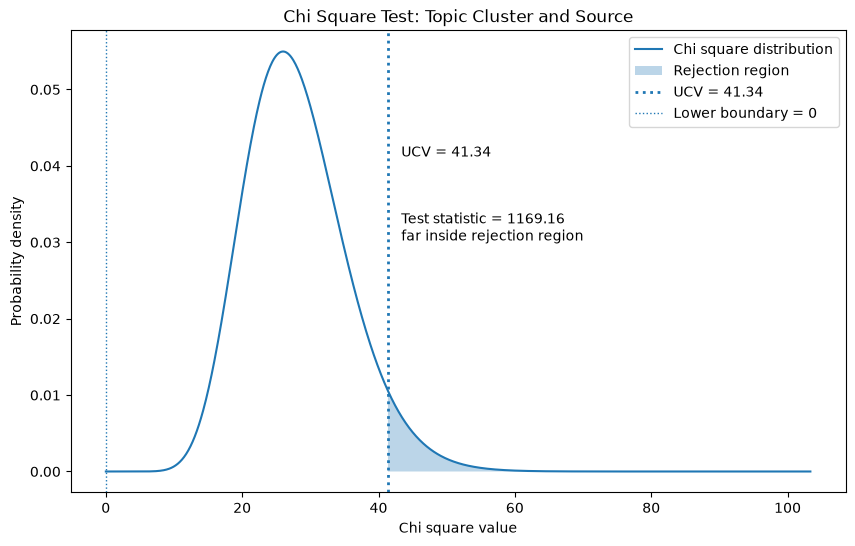

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

x_max = critical_value * 2.5

x = np.linspace(
    0.01,
    x_max,
    1000
)

y = chi2.pdf(
    x,
    dof
)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    y,
    label="Chi square distribution"
)

rejection_x = x[x >= critical_value]

plt.fill_between(
    rejection_x,
    chi2.pdf(rejection_x, dof),
    alpha=0.3,
    label="Rejection region"
)

plt.axvline(
    critical_value,
    linestyle=":",
    linewidth=2,
    label=f"UCV = {critical_value:.2f}"
)

plt.axvline(
    0,
    linestyle=":",
    linewidth=1,
    label="Lower boundary = 0"
)

plt.text(
    critical_value + 2,
    max(y) * 0.75,
    f"UCV = {critical_value:.2f}"
)

plt.text(
    critical_value + 2,
    max(y) * 0.55,
    f"Test statistic = {chi2_stat:.2f}\nfar inside rejection region"
)

plt.xlabel("Chi square value")
plt.ylabel("Probability density")
plt.title("Chi Square Test: Topic Cluster and Source")

plt.legend()

plt.show()

In [53]:
n = source_test.to_numpy().sum()

rows, columns = source_test.shape

cramers_v = np.sqrt(
    chi2_stat /
    (
        n * min(
            rows - 1,
            columns - 1
        )
    )
)

print("Cramer's V:", round(cramers_v, 3))

Cramer's V: 0.788


| Measure                    |        Result | Interpretation                                   |
| -------------------------- | ------------: | ------------------------------------------------ |
| Books tested               |          1881 | Both source records excluded only from inference |
| Minimum expected frequency |          8.94 | Assumption satisfied                             |
| Expected cells below 5     |             0 | Assumption satisfied                             |
| Alpha                      |          0.05 | Significance threshold                           |
| Chi square statistic       |      1169.161 | Extremely large                                  |
| Degrees of freedom         |            28 | Based on 29 clusters and 2 sources               |
| Upper critical value       |        41.337 | Start of rejection region                        |
| P value                    | 2.02 × 10⁻²²⁸ | Far below 0.05                                   |
| Decision                   |     Reject H0 | Significant association                          |
| Cramer's V                 |         0.788 | Strong association                               |

Explanation 1

LeadershipNow and Open Library genuinely contain
different types of leadership books

Explanation 2

Differences in metadata completeness and available text
are influencing the clustering algorithm

In [56]:
representative_books_29.columns.tolist()

['cluster',
 'cluster_size',
 'rank',
 'book_id',
 'title',
 'authors',
 'distance_to_centroid']

In [57]:
cluster_terms_29.columns.tolist()

['cluster', 'cluster_size', 'top_terms']

In [58]:
cluster_interpretation_29.columns.tolist()

['cluster',
 'cluster_size',
 'top_terms',
 'representative_titles',
 'representative_authors']

In [59]:
representative_books_29.head(10)

,cluster,cluster_size,rank,book_id,title,authors,distance_to_centroid
0,0,47,1,BOOK00605,Performance Management for Dummies,Dummies Staff Herman Aguinis,0.496095
1,0,47,2,BOOK00569,Performance management systems,Arup Varma,0.519037
2,0,47,3,BOOK00606,Performance Management (Acca),Kaplan Publishing,0.574372
3,0,47,4,BOOK00579,Performance management,Ralph R Smith,0.587042
4,0,47,5,BOOK00573,Managing performance,Michael Armstrong Angela Baron,0.607148
5,1,42,1,BOOK00266,Servant Leadership,Pastor Cecil Hollaway,0.350175
6,1,42,2,BOOK00264,Servant Leadership Roadmap,Cara H Bramlett,0.380875
7,1,42,3,BOOK00277,Servant Leadership in diakonischen Unternehmen,Mathias Hartmann,0.391266
8,1,42,4,BOOK00273,Understanding Servant Leadership,Chad Audi,0.454350
9,1,42,5,BOOK00246,Servant leadership,Dirk van Dierendonck,0.460498


In [60]:
cluster_terms_29.head()

,cluster,cluster_size,top_terms
0,0,47,"performance, performance management, managemen..."
1,1,42,"servant, servant leadership, leadership, relig..."
2,2,54,"project, project management, management, engin..."
3,3,455,"robert, business, brian, management, richard, ..."
4,4,127,"leadership, leadership development, developmen..."


In [61]:
cluster_interpretation_29.head()

,cluster,cluster_size,top_terms,representative_titles,representative_authors
0,0,47,"performance, performance management, managemen...",Performance Management for Dummies | Performan...,Dummies Staff Herman Aguinis | Arup Varma | Ka...
1,1,42,"servant, servant leadership, leadership, relig...",Servant Leadership | Servant Leadership Roadma...,Pastor Cecil Hollaway | Cara H Bramlett | Math...
2,2,54,"project, project management, management, engin...",Project Management in Perspective | Contempora...,Theuns Oosthuizen | Timothy Kloppenborg Kathry...
3,3,455,"robert, business, brian, management, richard, ...",Leaders Eat Last | Tribal leadership | Uniting...,Simon Sinek | David Logan Dave Logan John King...
4,4,127,"leadership, leadership development, developmen...",Kepemimpinan = | The Soil of Leadership | Flow...,Karjadi M. | Britt Yamamoto | Gaelle Devins | ...


In [62]:
final_cluster_sizes = (
    topic_cluster_books_29["topic_cluster"]
    .value_counts()
    .sort_index()
)

final_cluster_sizes

topic_cluster
0      82
1      56
2      33
3      70
4      33
5      33
6      47
7     185
8      42
9      42
10     53
11    184
12     18
13     72
14     41
15     27
16     23
17     28
18     50
19     39
20     57
21     45
22     27
23     47
24     49
25    108
26     26
27     82
28    285
Name: count, dtype: int64

In [63]:
representative_cluster_sizes = (
    representative_books_29[
        ["cluster", "cluster_size"]
    ]
    .drop_duplicates()
    .set_index("cluster")["cluster_size"]
    .sort_index()
)

representative_cluster_sizes

cluster
0      47
1      42
2      54
3     455
4     127
5      51
6      82
7      40
8      32
9      24
10     46
11     30
12     52
13     35
14     24
15     36
16     47
17     46
18     68
19     51
20     57
21     85
22     48
23     31
24    121
25     28
26    233
27     28
28     20
Name: cluster_size, dtype: int64

In [64]:
cluster_size_check = pd.DataFrame({
    "final_cluster_size": final_cluster_sizes,
    "representative_table_size": representative_cluster_sizes
})

cluster_size_check["difference"] = (
    cluster_size_check["final_cluster_size"]
    - cluster_size_check["representative_table_size"]
)

cluster_size_check

,final_cluster_size,representative_table_size,difference
0,82,47,35
1,56,42,14
2,33,54,-21
3,70,455,-385
4,33,127,-94
5,33,51,-18
6,47,82,-35
7,185,40,145
8,42,32,10
9,42,24,18


representative_books_29
belongs to an earlier clustering solution

topic_cluster_books_29
contains the current final cluster assignments

In [65]:
terms_cluster_sizes = (
    cluster_terms_29[
        ["cluster", "cluster_size"]
    ]
    .drop_duplicates()
    .set_index("cluster")["cluster_size"]
    .sort_index()
)

terms_size_check = pd.DataFrame({
    "final_cluster_size": final_cluster_sizes,
    "terms_table_size": terms_cluster_sizes
})

terms_size_check["difference"] = (
    terms_size_check["final_cluster_size"]
    - terms_size_check["terms_table_size"]
)

terms_size_check

,final_cluster_size,terms_table_size,difference
0,82,47,35
1,56,42,14
2,33,54,-21
3,70,455,-385
4,33,127,-94
5,33,51,-18
6,47,82,-35
7,185,40,145
8,42,32,10
9,42,24,18


In [66]:
topic_cluster_books_29.columns.tolist()

['book_id',
 'canonical_title',
 'authors',
 'description',
 'subjects',
 'first_publish_year',
 'average_rating',
 'ratings_count',
 'edition_count',
 'want_to_read_count',
 'currently_reading_count',
 'already_read_count',
 'cover_url',
 'openlibrary_key',
 'source_openlibrary',
 'source_leadershipnow',
 'publication_year_observed',
 'title_normalized',
 'has_authors',
 'has_description',
 'has_subjects',
 'has_cover',
 'has_rating',
 'has_engagement',
 'has_extended_text',
 'has_first_publish_year',
 'has_observed_publication_year',
 'book_age_from_first_publish',
 'years_since_observed_publication',
 'log1p_ratings_count',
 'log1p_want_to_read_count',
 'log1p_currently_reading_count',
 'log1p_already_read_count',
 'log1p_edition_count',
 'total_reader_engagement',
 'log1p_total_reader_engagement',
 'format',
 'page_count',
 'has_edition_metadata',
 'has_page_count',
 'is_hardcover',
 'is_paperback',
 'log1p_page_count',
 'format_edition',
 'page_count_edition',
 'has_edition_metada

In [67]:
print("Books:", len(topic_cluster_books_29))
print("Clusters:", topic_cluster_books_29["topic_cluster"].nunique())

print(
    "Missing topic text:",
    topic_cluster_books_29["topic_content_text"].isna().sum()
)

print(
    "Missing cluster:",
    topic_cluster_books_29["topic_cluster"].isna().sum()
)

Books: 1884
Clusters: 29
Missing topic text: 0
Missing cluster: 0


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    topic_cluster_books_29["topic_content_text"].fillna("")
)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF IDF shape:", tfidf_matrix.shape)
print("Number of terms:", len(feature_names))

TF IDF shape: (1884, 4336)
Number of terms: 4336


In [72]:
import numpy as np
import pandas as pd

final_cluster_terms = []

for cluster in sorted(
    topic_cluster_books_29["topic_cluster"].unique()
):

    cluster_mask = (
        topic_cluster_books_29["topic_cluster"] == cluster
    )

    row_indices = np.where(
        cluster_mask.to_numpy()
    )[0]

    cluster_matrix = tfidf_matrix[row_indices]

    mean_scores = np.asarray(
        cluster_matrix.mean(axis=0)
    ).ravel()

    top_indices = mean_scores.argsort()[-10:][::-1]

    top_terms = [
        feature_names[index]
        for index in top_indices
    ]

    final_cluster_terms.append({
        "cluster": cluster,
        "cluster_size": len(row_indices),
        "top_terms": ", ".join(top_terms)
    })

final_cluster_terms_29 = pd.DataFrame(
    final_cluster_terms
)

final_cluster_terms_29

,cluster,cluster_size,top_terms
0,0,82,"mindsetzzfieldboundaryzzzzfieldboundaryzz, art..."
1,1,56,"organizational, behavior, organizational behav..."
2,2,33,"team, teamzzfieldboundaryzzzzfieldboundaryzz, ..."
3,3,70,"future, futurezzfieldboundaryzzzzfieldboundary..."
4,4,33,"decision, making, decision making, prise, déci..."
5,5,33,"leaderzzfieldboundaryzzzzfieldboundaryzz, lead..."
6,6,47,"communication, language, communicationzzfieldb..."
7,7,185,"right, win, manzzfieldboundaryzzzzfieldboundar..."
8,8,42,"servant, servant leadership, leadership, serva..."
9,9,42,"change, changezzfieldboundaryzzzzfieldboundary..."


In [73]:
final_cluster_terms_29[
    ["cluster", "cluster_size"]
]

,cluster,cluster_size
0,0,82
1,1,56
2,2,33
3,3,70
4,4,33
5,5,33
6,6,47
7,7,185
8,8,42
9,9,42


In [74]:
final_terms_size_check = pd.DataFrame({
    "final_cluster_size": final_cluster_sizes,
    "new_terms_size": (
        final_cluster_terms_29
        .set_index("cluster")["cluster_size"]
    )
})

final_terms_size_check["difference"] = (
    final_terms_size_check["final_cluster_size"]
    - final_terms_size_check["new_terms_size"]
)

final_terms_size_check

,final_cluster_size,new_terms_size,difference
0,82,82,0
1,56,56,0
2,33,33,0
3,70,70,0
4,33,33,0
5,33,33,0
6,47,47,0
7,185,185,0
8,42,42,0
9,42,42,0


In [75]:
topic_cluster_books_29["topic_text_clean"] = (
    topic_cluster_books_29["topic_content_text"]
    .fillna("")
    .str.replace(
        r"zzfieldboundaryz*",
        " ",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

topic_cluster_books_29[
    ["topic_content_text", "topic_text_clean"]
].head()

,topic_content_text,topic_text_clean
0,Principle-Centered Leadershipzzfieldboundaryzz...,Principle-Centered Leadership Leadership Psych...
1,Leadership in OrganizationszzfieldboundaryzzOr...,Leadership in Organizations Organisation Prise...
2,Kepemimpinan =zzfieldboundaryzzLeadershipzzfie...,Kepemimpinan = Leadership
3,Spiritual leadershipzzfieldboundaryzzChristian...,Spiritual leadership Christian leadership Lead...
4,"LeadershipzzfieldboundaryzzCas, Études de Leid...","Leadership Cas, Études de Leiderschap Leadersh..."


In [76]:
boundary_check = (
    topic_cluster_books_29["topic_text_clean"]
    .str.contains(
        "zzfieldboundary",
        case=False,
        na=False
    )
    .sum()
)

print("Rows still containing boundary marker:", boundary_check)

Rows still containing boundary marker: 0


In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    topic_cluster_books_29["topic_text_clean"]
)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF IDF shape:", tfidf_matrix.shape)
print("Number of terms:", len(feature_names))

TF IDF shape: (1884, 4365)
Number of terms: 4365


In [78]:
import numpy as np
import pandas as pd

final_cluster_terms = []

for cluster in sorted(
    topic_cluster_books_29["topic_cluster"].unique()
):

    cluster_mask = (
        topic_cluster_books_29["topic_cluster"] == cluster
    )

    row_indices = np.where(
        cluster_mask.to_numpy()
    )[0]

    cluster_matrix = tfidf_matrix[row_indices]

    mean_scores = np.asarray(
        cluster_matrix.mean(axis=0)
    ).ravel()

    top_indices = mean_scores.argsort()[-10:][::-1]

    top_terms = [
        feature_names[index]
        for index in top_indices
    ]

    final_cluster_terms.append({
        "cluster": cluster,
        "cluster_size": len(row_indices),
        "top_terms": ", ".join(top_terms)
    })

final_cluster_terms_29 = pd.DataFrame(
    final_cluster_terms
)

final_cluster_terms_29

,cluster,cluster_size,top_terms
0,0,82,"fieldboundaryzz, mindset, mindset fieldboundar..."
1,1,56,"behavior, organizational behavior, organizatio..."
2,2,33,"team, team leadership, leadership, team fieldb..."
3,3,70,"fieldboundaryzz, future, think, future fieldbo..."
4,4,33,"decision, making, decision making, fieldbounda..."
5,5,33,"leader fieldboundaryzz, leader, fieldboundaryz..."
6,6,47,"communication, language, communication communi..."
7,7,185,"fieldboundaryzz, right, win, time, success, ma..."
8,8,42,"servant, servant leadership, leadership, leade..."
9,9,42,"change, change management, management, change ..."


In [79]:
topic_cluster_books_29["topic_text_clean"] = (
    topic_cluster_books_29["topic_content_text"]
    .fillna("")
    .str.replace(
        r"z*fieldboundaryz*",
        " ",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

In [80]:
boundary_check = (
    topic_cluster_books_29["topic_text_clean"]
    .str.contains(
        "fieldboundary",
        case=False,
        na=False
    )
    .sum()
)

print(
    "Rows still containing boundary marker:",
    boundary_check
)

Rows still containing boundary marker: 0


In [81]:
topic_cluster_books_29[
    [
        "canonical_title",
        "topic_text_clean"
    ]
].head(10)

,canonical_title,topic_text_clean
0,Principle-Centered Leadership,Principle-Centered Leadership Leadership Psych...
1,Leadership in Organizations,Leadership in Organizations Organisation Prise...
2,Kepemimpinan =,Kepemimpinan = Leadership
3,Spiritual leadership,Spiritual leadership Christian leadership Lead...
4,Leadership,"Leadership Cas, Études de Leiderschap Leadersh..."
5,The 21 Irrefutable Laws of Leadership,The 21 Irrefutable Laws of Leadership Leadersh...
6,Leadership,Leadership Leadership Case studies Sociology F...
7,Leadership and performance beyond expectations,Leadership and performance beyond expectations...
8,A Higher Loyalty,A Higher Loyalty Politics and government Offic...
9,Leadership and Self Deception,Leadership and Self Deception Berrett Koehler ...


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    topic_cluster_books_29["topic_text_clean"]
)

feature_names = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print(
    "TF IDF shape:",
    tfidf_matrix.shape
)

print(
    "Number of terms:",
    len(feature_names)
)

TF IDF shape: (1884, 4195)
Number of terms: 4195


In [83]:
import numpy as np
import pandas as pd

final_cluster_terms = []

for cluster in sorted(
    topic_cluster_books_29[
        "topic_cluster"
    ].unique()
):

    cluster_mask = (
        topic_cluster_books_29[
            "topic_cluster"
        ] == cluster
    )

    row_indices = np.where(
        cluster_mask.to_numpy()
    )[0]

    cluster_matrix = (
        tfidf_matrix[row_indices]
    )

    mean_scores = np.asarray(
        cluster_matrix.mean(axis=0)
    ).ravel()

    top_indices = (
        mean_scores
        .argsort()[-10:][::-1]
    )

    top_terms = [
        feature_names[index]
        for index in top_indices
    ]

    final_cluster_terms.append({
        "cluster": cluster,
        "cluster_size": len(
            row_indices
        ),
        "top_terms": ", ".join(
            top_terms
        )
    })

final_cluster_terms_29 = pd.DataFrame(
    final_cluster_terms
)

final_cluster_terms_29

,cluster,cluster_size,top_terms
0,0,82,"mindset, art, new, advantage, startup, entrepr..."
1,1,56,"behavior, organizational behavior, organizatio..."
2,2,33,"team, team leadership, leadership, effective t..."
3,3,70,"future, think, self, excellence, war, want, st..."
4,4,33,"decision, making, decision making, prise, judg..."
5,5,33,"leader, driven leader, strong leader, strong, ..."
6,6,47,"communication, language, communication communi..."
7,7,185,"right, win, time, man, success, digital, build..."
8,8,42,"servant, servant leadership, leadership, leade..."
9,9,42,"change, change management, management, organiz..."


In [84]:
bad_terms = (
    final_cluster_terms_29[
        "top_terms"
    ]
    .str.contains(
        "fieldboundary",
        case=False,
        na=False
    )
    .sum()
)

print(
    "Clusters containing boundary terms:",
    bad_terms
)

Clusters containing boundary terms: 0


In [90]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd
import numpy as np

final_representative_books = []

for cluster in sorted(
    topic_cluster_books_29["topic_cluster"].unique()
):

    cluster_mask = (
        topic_cluster_books_29["topic_cluster"] == cluster
    )

    row_indices = np.where(
        cluster_mask.to_numpy()
    )[0]

    cluster_matrix = tfidf_matrix[row_indices]

    cluster_centroid = np.asarray(
        cluster_matrix.mean(axis=0)
    )

    distances = cosine_distances(
        cluster_matrix,
        cluster_centroid
    ).ravel()

    top_positions = distances.argsort()[:5]

    for rank, position in enumerate(
        top_positions,
        start=1
    ):

        row_index = row_indices[position]

        book = topic_cluster_books_29.iloc[row_index]

        final_representative_books.append({
            "cluster": cluster,
            "cluster_size": len(row_indices),
            "rank": rank,
            "book_id": book["book_id"],
            "title": book["canonical_title"],
            "authors": book["authors"],
            "distance_to_centroid": distances[position]
        })

final_representative_books_29 = pd.DataFrame(
    final_representative_books
)

final_representative_books_29

,cluster,cluster_size,rank,book_id,title,authors,distance_to_centroid
0,0,82,1,BOOK02062,A Platform Mindset,['Marcus Fontoura'],0.379655
1,0,82,2,BOOK01663,Unstoppable Mindset,['Alden Mills'],0.379655
2,0,82,3,BOOK01664,The Hacker Mindset,['Garrett Gee'],0.379655
3,0,82,4,BOOK01631,Aliveness Mindset,['Jack Craven'],0.379655
4,0,82,5,BOOK01670,The Entrepreneurial Mindset Advantage,['Gary G. Schoeniger'],0.524835
...,...,...,...,...,...,...,...
140,28,285,1,BOOK01534,Sideline CEO,['Marty Smith / Foreword by Tim Tebow'],0.686592
141,28,285,2,BOOK01413,How To Be A CEO,['Ben Renshaw'],0.686592
142,28,285,3,BOOK01711,From Welfare To CEO,['Korena Keys'],0.686592
143,28,285,4,BOOK02010,The Detour CEO,['Paul Perreault'],0.686592


In [91]:
print(
    "Rows:",
    len(final_representative_books_29)
)

print(
    "Clusters:",
    final_representative_books_29["cluster"].nunique()
)

Rows: 145
Clusters: 29


In [92]:
representative_size_check = (
    final_representative_books_29[
        ["cluster", "cluster_size"]
    ]
    .drop_duplicates()
    .set_index("cluster")
)

representative_size_check["final_cluster_size"] = (
    final_cluster_sizes
)

representative_size_check["difference"] = (
    representative_size_check["cluster_size"]
    - representative_size_check["final_cluster_size"]
)

representative_size_check

,cluster_size,final_cluster_size,difference
cluster,,,
0,82,82,0
1,56,56,0
2,33,33,0
3,70,70,0
4,33,33,0
5,33,33,0
6,47,47,0
7,185,185,0
8,42,42,0


In [93]:
final_representative_books_29[
    [
        "cluster",
        "cluster_size",
        "rank",
        "title",
        "authors",
        "distance_to_centroid"
    ]
]

,cluster,cluster_size,rank,title,authors,distance_to_centroid
0,0,82,1,A Platform Mindset,['Marcus Fontoura'],0.379655
1,0,82,2,Unstoppable Mindset,['Alden Mills'],0.379655
2,0,82,3,The Hacker Mindset,['Garrett Gee'],0.379655
3,0,82,4,Aliveness Mindset,['Jack Craven'],0.379655
4,0,82,5,The Entrepreneurial Mindset Advantage,['Gary G. Schoeniger'],0.524835
...,...,...,...,...,...,...
140,28,285,1,Sideline CEO,['Marty Smith / Foreword by Tim Tebow'],0.686592
141,28,285,2,How To Be A CEO,['Ben Renshaw'],0.686592
142,28,285,3,From Welfare To CEO,['Korena Keys'],0.686592
143,28,285,4,The Detour CEO,['Paul Perreault'],0.686592


In [94]:
clusters_to_review = [
    7,
    11,
    16,
    22,
    26,
    28
]

final_representative_books_29[
    final_representative_books_29[
        "cluster"
    ].isin(clusters_to_review)
][
    [
        "cluster",
        "rank",
        "title",
        "authors",
        "distance_to_centroid"
    ]
]

,cluster,rank,title,authors,distance_to_centroid
35,7,1,"Right Leader, Right Time",['Robert Jordan and Olivia Wagner'],0.601354
36,7,2,Get Pay Right,['Kent Plunkett and Heather Bussing'],0.699732
37,7,3,The Right Call,['Sally Jenkins'],0.699732
38,7,4,Left and Right of the Boom,['Rob Campbell'],0.699732
39,7,5,Servant-leadership across cultures,['Alfons Trompenaars'],0.717653
55,11,1,Culture Is the Way,['Matt Mayberry'],0.520036
56,11,2,Curative Culture,['Douglas K Shaw'],0.615526
57,11,3,Conquer Your Culture,['David Komar'],0.615526
58,11,4,For the Culture,['Marcus Collins'],0.615526
59,11,5,Culture Matters,['Jenni Catron'],0.633006


In [95]:
representative_summary = (
    final_representative_books_29
    .groupby("cluster")
    .agg(
        representative_titles=(
            "title",
            lambda x: " | ".join(x)
        ),
        average_centroid_distance=(
            "distance_to_centroid",
            "mean"
        )
    )
    .reset_index()
)

final_cluster_interpretation_29 = (
    final_cluster_terms_29
    .merge(
        representative_summary,
        on="cluster",
        how="left"
    )
)

final_cluster_interpretation_29[
    "average_centroid_distance"
] = (
    final_cluster_interpretation_29[
        "average_centroid_distance"
    ].round(3)
)

final_cluster_interpretation_29

,cluster,cluster_size,top_terms,representative_titles,average_centroid_distance
0,0,82,"mindset, art, new, advantage, startup, entrepr...",A Platform Mindset | Unstoppable Mindset | The...,0.409
1,1,56,"behavior, organizational behavior, organizatio...",Organizational Behavior | Organizational behav...,0.093
2,2,33,"team, team leadership, leadership, effective t...",Team leadership | Team Leadership | Team Leade...,0.118
3,3,70,"future, think, self, excellence, war, want, st...",Stewards of the Future | Future Tense | Invent...,0.497
4,4,33,"decision, making, decision making, prise, judg...",DECISION MAKING | Creative decision making | J...,0.242
5,5,33,"leader, driven leader, strong leader, strong, ...",You're the Leader. Now What? | We the Leader |...,0.027
6,6,47,"communication, language, communication communi...",InCredible Communication | Communication | Cor...,0.293
7,7,185,"right, win, time, man, success, digital, build...","Right Leader, Right Time | Get Pay Right | The...",0.684
8,8,42,"servant, servant leadership, leadership, leade...",Servant Leadership | Servant Leadership | Serv...,0.100
9,9,42,"change, change management, management, organiz...",Change management | Change Management | Change...,0.207


In [96]:
print(
    "Clusters:",
    len(final_cluster_interpretation_29)
)

final_cluster_interpretation_29[
    [
        "cluster",
        "cluster_size",
        "average_centroid_distance"
    ]
].sort_values(
    "average_centroid_distance"
)

Clusters: 29


,cluster,cluster_size,average_centroid_distance
22,22,27,0.023
5,5,33,0.027
15,15,27,0.036
20,20,57,0.042
18,18,50,0.045
25,25,108,0.090
16,16,23,0.091
1,1,56,0.093
24,24,49,0.099
8,8,42,0.100


In [97]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd

cluster_cohesion_results = []

for cluster in sorted(
    topic_cluster_books_29["topic_cluster"].unique()
):

    cluster_mask = (
        topic_cluster_books_29["topic_cluster"] == cluster
    )

    row_indices = np.where(
        cluster_mask.to_numpy()
    )[0]

    cluster_matrix = tfidf_matrix[row_indices]

    cluster_centroid = np.asarray(
        cluster_matrix.mean(axis=0)
    )

    distances = cosine_distances(
        cluster_matrix,
        cluster_centroid
    ).ravel()

    cluster_cohesion_results.append({
        "cluster": cluster,
        "cluster_size": len(row_indices),
        "mean_distance_to_centroid": distances.mean(),
        "median_distance_to_centroid": np.median(distances),
        "max_distance_to_centroid": distances.max()
    })

cluster_cohesion_29 = pd.DataFrame(
    cluster_cohesion_results
)

cluster_cohesion_29 = (
    cluster_cohesion_29
    .sort_values(
        "mean_distance_to_centroid"
    )
)

cluster_cohesion_29

,cluster,cluster_size,mean_distance_to_centroid,median_distance_to_centroid,max_distance_to_centroid
22,22,27,0.318550,0.371425,0.706164
24,24,49,0.340670,0.334649,0.666338
16,16,23,0.340994,0.391554,0.528509
20,20,57,0.342664,0.335439,0.682588
18,18,50,0.361570,0.392393,0.721819
23,23,47,0.365621,0.342717,0.695587
12,12,18,0.368550,0.350997,0.601658
15,15,27,0.380300,0.421254,0.694571
5,5,33,0.380652,0.445516,0.599745
1,1,56,0.396443,0.413353,0.693245


In [98]:
final_cluster_interpretation_29 = (
    final_cluster_interpretation_29
    .merge(
        cluster_cohesion_29[
            [
                "cluster",
                "mean_distance_to_centroid",
                "median_distance_to_centroid",
                "max_distance_to_centroid"
            ]
        ],
        on="cluster",
        how="left"
    )
)

final_cluster_interpretation_29[
    [
        "cluster",
        "cluster_size",
        "average_centroid_distance",
        "mean_distance_to_centroid",
        "median_distance_to_centroid",
        "max_distance_to_centroid"
    ]
].sort_values(
    "mean_distance_to_centroid"
)

,cluster,cluster_size,average_centroid_distance,mean_distance_to_centroid,median_distance_to_centroid,max_distance_to_centroid
22,22,27,0.023,0.318550,0.371425,0.706164
24,24,49,0.099,0.340670,0.334649,0.666338
16,16,23,0.091,0.340994,0.391554,0.528509
20,20,57,0.042,0.342664,0.335439,0.682588
18,18,50,0.045,0.361570,0.392393,0.721819
23,23,47,0.103,0.365621,0.342717,0.695587
12,12,18,0.244,0.368550,0.350997,0.601658
15,15,27,0.036,0.380300,0.421254,0.694571
5,5,33,0.027,0.380652,0.445516,0.599745
1,1,56,0.093,0.396443,0.413353,0.693245


In [99]:
q1 = cluster_cohesion_29[
    "mean_distance_to_centroid"
].quantile(0.25)

median = cluster_cohesion_29[
    "mean_distance_to_centroid"
].median()

q3 = cluster_cohesion_29[
    "mean_distance_to_centroid"
].quantile(0.75)

print("Q1:", round(q1, 3))
print("Median:", round(median, 3))
print("Q3:", round(q3, 3))

Q1: 0.38
Median: 0.449
Q3: 0.575


In [100]:
cluster_cohesion_29["cohesion_group"] = np.select(
    [
        cluster_cohesion_29[
            "mean_distance_to_centroid"
        ] <= q1,

        cluster_cohesion_29[
            "mean_distance_to_centroid"
        ] <= median,

        cluster_cohesion_29[
            "mean_distance_to_centroid"
        ] <= q3
    ],
    [
        "Most compact",
        "Moderately compact",
        "Moderately broad"
    ],
    default="Broadest"
)

cluster_cohesion_29[
    [
        "cluster",
        "cluster_size",
        "mean_distance_to_centroid",
        "cohesion_group"
    ]
].sort_values(
    "mean_distance_to_centroid"
)

,cluster,cluster_size,mean_distance_to_centroid,cohesion_group
22,22,27,0.318550,Most compact
24,24,49,0.340670,Most compact
16,16,23,0.340994,Most compact
20,20,57,0.342664,Most compact
18,18,50,0.361570,Most compact
23,23,47,0.365621,Most compact
12,12,18,0.368550,Most compact
15,15,27,0.380300,Most compact
5,5,33,0.380652,Moderately compact
1,1,56,0.396443,Moderately compact


In [101]:
final_cluster_interpretation_29 = (
    final_cluster_interpretation_29
    .merge(
        cluster_cohesion_29[
            [
                "cluster",
                "cohesion_group"
            ]
        ],
        on="cluster",
        how="left"
    )
)

final_cluster_interpretation_29[
    [
        "cluster",
        "cluster_size",
        "top_terms",
        "mean_distance_to_centroid",
        "cohesion_group"
    ]
]

,cluster,cluster_size,top_terms,mean_distance_to_centroid,cohesion_group
0,0,82,"mindset, art, new, advantage, startup, entrepr...",0.794508,Broadest
1,1,56,"behavior, organizational behavior, organizatio...",0.396443,Moderately compact
2,2,33,"team, team leadership, leadership, effective t...",0.446914,Moderately compact
3,3,70,"future, think, self, excellence, war, want, st...",0.775839,Broadest
4,4,33,"decision, making, decision making, prise, judg...",0.510835,Moderately broad
5,5,33,"leader, driven leader, strong leader, strong, ...",0.380652,Moderately compact
6,6,47,"communication, language, communication communi...",0.534248,Moderately broad
7,7,185,"right, win, time, man, success, digital, build...",0.877948,Broadest
8,8,42,"servant, servant leadership, leadership, leade...",0.399867,Moderately compact
9,9,42,"change, change management, management, organiz...",0.478248,Moderately broad


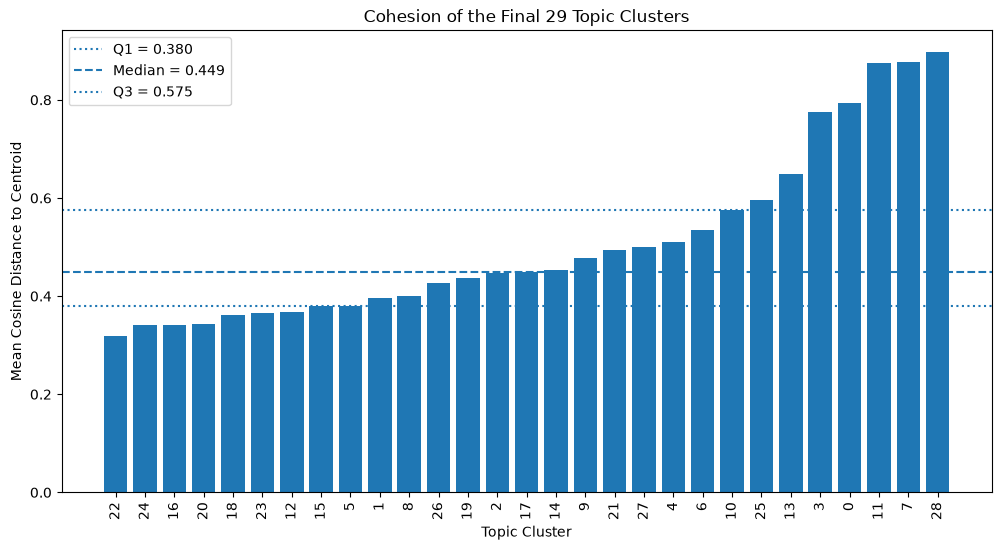

In [102]:
cohesion_plot = (
    cluster_cohesion_29
    .sort_values(
        "mean_distance_to_centroid"
    )
)

plt.figure(figsize=(12, 6))

plt.bar(
    cohesion_plot["cluster"].astype(str),
    cohesion_plot["mean_distance_to_centroid"]
)

plt.axhline(
    q1,
    linestyle=":",
    label=f"Q1 = {q1:.3f}"
)

plt.axhline(
    median,
    linestyle="--",
    label=f"Median = {median:.3f}"
)

plt.axhline(
    q3,
    linestyle=":",
    label=f"Q3 = {q3:.3f}"
)

plt.xlabel("Topic Cluster")
plt.ylabel("Mean Cosine Distance to Centroid")
plt.title("Cohesion of the Final 29 Topic Clusters")

plt.xticks(rotation=90)
plt.legend()

plt.show()

### Cluster Cohesion Interpretation

Cluster cohesion was evaluated using the mean cosine distance of every book from its respective cluster centroid. Lower distances indicate that books within a cluster are more similar to the cluster's central content profile, while higher distances indicate greater thematic variation.

Because cosine distance has no universal threshold that determines whether a topic cluster is acceptable, cohesion was evaluated relative to the distribution of the 29 final clusters.

The first quartile was approximately 0.380, the median was approximately 0.449, and the third quartile was approximately 0.575.

Clusters such as Power and Influence, Operations Management, Human Resource Management, Emotional Intelligence, and Project Management showed comparatively high internal cohesion.

In contrast, Clusters 0, 3, 7, 11, 13, 25, and 28 showed greater thematic spread. Cluster 28 was particularly broad, containing 285 books with a mean cosine distance of approximately 0.897.

These results indicate that the final clustering solution contains several clearly defined topic groups alongside broader clusters that should be interpreted more cautiously in the recommendation system.

29 final clusters
↓
Cluster sizes validated
↓
Technical text artifacts removed
↓
Top terms regenerated
↓
Representative books regenerated
↓
Representative books validated
↓
Source association tested
↓
Chi square significant
↓
Cramer's V = 0.788
↓
Whole cluster cohesion evaluated

## Final Clustering Validation Summary

The final 29 cluster solution was validated using several complementary methods.

Cluster sizes and representative books were checked against the final book level assignments to ensure that all interpretation tables were synchronized with the selected clustering model.

A Chi square test found a statistically significant association between book source and topic cluster membership, while Cramer's V indicated a strong relationship. This suggests that source specific characteristics and metadata availability may influence some cluster assignments.

Topic terms and representative books nevertheless showed that many clusters correspond to recognizable leadership and management themes, including Organizational Behavior, Team Leadership, Servant Leadership, Change Management, Emotional Intelligence, Human Resource Management, Project Management, Operations Management, and Strategic Management.

Whole cluster cohesion was evaluated using cosine distance to each cluster centroid. Several clusters demonstrated strong internal similarity, while larger clusters such as Clusters 7, 11, and 28 showed substantially greater thematic variation.

Overall, the clustering solution provides useful thematic segmentation for the recommendation system, although broader clusters should be interpreted and used more cautiously.

Final feature representation
↓
Standardization if applicable
↓
PCA
↓
Explained variance
↓
Scree plot
↓
Cumulative explained variance
↓
2D PCA
↓
3D PCA
↓
Color by source group
↓
Color by topic cluster
↓
Compare with Chi square and cohesion findings

In [104]:
cluster_labels = {
    0: "Entrepreneurial and Growth Mindset",
    1: "Organizational Behavior",
    2: "Team Leadership",
    3: "Future Thinking and Personal Development",
    4: "Decision Making",
    5: "Leader Identity and Practice",
    6: "Communication",
    7: "Broad Leadership and Success",
    8: "Servant Leadership",
    9: "Change Management",
    10: "Leadership Development",
    11: "Organizational Culture and Trust",
    12: "Information Technology Management",
    13: "General Business and Management",
    14: "Performance Management",
    15: "Workplace and Generational Dynamics",
    16: "Leading Self and Others",
    17: "People Management",
    18: "Emotional Intelligence",
    19: "Executive Leadership",
    20: "Human Resource Management",
    21: "Innovation Management",
    22: "Power and Influence",
    23: "Project Management",
    24: "Operations Management",
    25: "Transformational Leadership",
    26: "Contemporary Leadership Practice",
    27: "Strategic Management and Planning",
    28: "CEO and Executive Transformation"
}

In [105]:
topic_cluster_books_29["cluster_label"] = (
    topic_cluster_books_29["topic_cluster"]
    .map(cluster_labels)
)

topic_cluster_books_29[
    [
        "book_id",
        "canonical_title",
        "topic_cluster",
        "cluster_label"
    ]
].head()

,book_id,canonical_title,topic_cluster,cluster_label
0,BOOK00001,Principle-Centered Leadership,7,Broad Leadership and Success
1,BOOK00002,Leadership in Organizations,4,Decision Making
2,BOOK00003,Kepemimpinan =,25,Transformational Leadership
3,BOOK00004,Spiritual leadership,25,Transformational Leadership
4,BOOK00005,Leadership,25,Transformational Leadership


In [106]:
print(
    "Missing cluster labels:",
    topic_cluster_books_29[
        "cluster_label"
    ].isna().sum()
)

Missing cluster labels: 0


In [107]:
final_cluster_interpretation_29[
    "cluster_label"
] = (
    final_cluster_interpretation_29[
        "cluster"
    ].map(cluster_labels)
)

In [108]:
final_cluster_interpretation_29 = (
    final_cluster_interpretation_29[
        [
            "cluster",
            "cluster_label",
            "cluster_size",
            "top_terms",
            "representative_titles",
            "average_centroid_distance",
            "mean_distance_to_centroid",
            "median_distance_to_centroid",
            "max_distance_to_centroid",
            "cohesion_group"
        ]
    ]
)

final_cluster_interpretation_29

,cluster,cluster_label,cluster_size,top_terms,representative_titles,average_centroid_distance,mean_distance_to_centroid,median_distance_to_centroid,max_distance_to_centroid,cohesion_group
0,0,Entrepreneurial and Growth Mindset,82,"mindset, art, new, advantage, startup, entrepr...",A Platform Mindset | Unstoppable Mindset | The...,0.409,0.794508,0.836619,1.000000,Broadest
1,1,Organizational Behavior,56,"behavior, organizational behavior, organizatio...",Organizational Behavior | Organizational behav...,0.093,0.396443,0.413353,0.693245,Moderately compact
2,2,Team Leadership,33,"team, team leadership, leadership, effective t...",Team leadership | Team Leadership | Team Leade...,0.118,0.446914,0.493052,0.710623,Moderately compact
3,3,Future Thinking and Personal Development,70,"future, think, self, excellence, war, want, st...",Stewards of the Future | Future Tense | Invent...,0.497,0.775839,0.802344,0.933148,Broadest
4,4,Decision Making,33,"decision, making, decision making, prise, judg...",DECISION MAKING | Creative decision making | J...,0.242,0.510835,0.460445,0.930248,Moderately broad
5,5,Leader Identity and Practice,33,"leader, driven leader, strong leader, strong, ...",You're the Leader. Now What? | We the Leader |...,0.027,0.380652,0.445516,0.599745,Moderately compact
6,6,Communication,47,"communication, language, communication communi...",InCredible Communication | Communication | Cor...,0.293,0.534248,0.543805,0.775628,Moderately broad
7,7,Broad Leadership and Success,185,"right, win, time, man, success, digital, build...","Right Leader, Right Time | Get Pay Right | The...",0.684,0.877948,0.891322,1.000000,Broadest
8,8,Servant Leadership,42,"servant, servant leadership, leadership, leade...",Servant Leadership | Servant Leadership | Serv...,0.100,0.399867,0.368686,0.772093,Moderately compact
9,9,Change Management,42,"change, change management, management, organiz...",Change management | Change Management | Change...,0.207,0.478248,0.481078,0.832632,Moderately broad


In [109]:
final_representative_books_29[
    "cluster_label"
] = (
    final_representative_books_29[
        "cluster"
    ].map(cluster_labels)
)

In [110]:
final_representative_books_29[
    [
        "cluster",
        "cluster_label",
        "rank",
        "title",
        "authors"
    ]
].head(10)

,cluster,cluster_label,rank,title,authors
0,0,Entrepreneurial and Growth Mindset,1,A Platform Mindset,['Marcus Fontoura']
1,0,Entrepreneurial and Growth Mindset,2,Unstoppable Mindset,['Alden Mills']
2,0,Entrepreneurial and Growth Mindset,3,The Hacker Mindset,['Garrett Gee']
3,0,Entrepreneurial and Growth Mindset,4,Aliveness Mindset,['Jack Craven']
4,0,Entrepreneurial and Growth Mindset,5,The Entrepreneurial Mindset Advantage,['Gary G. Schoeniger']
5,1,Organizational Behavior,1,Organizational Behavior,"['Christopher P. Neck', 'Jeffery D. Houghton',..."
6,1,Organizational Behavior,2,Organizational behavior,"['Afsaneh Nahavandi', 'Ali R. Malekzadeh']"
7,1,Organizational Behavior,3,Organizational Behavior,['Ricky W. Griffin']
8,1,Organizational Behavior,4,Organizational behavior,"['Angelo Kinicki', 'Robert Kreitner']"
9,1,Organizational Behavior,5,Organizational Behavior,"['Mary Uhl-Bien', 'Ronald F. Piccolo', 'Scherm..."


In [111]:
cluster_books_path = (
    PROCESSED_DIR /
    "books_with_final_topic_clusters.csv"
)

cluster_summary_path = (
    PROCESSED_DIR /
    "final_topic_cluster_summary.csv"
)

representative_books_path = (
    PROCESSED_DIR /
    "final_cluster_representative_books.csv"
)

In [112]:
topic_cluster_books_29.to_csv(
    cluster_books_path,
    index=False
)

final_cluster_interpretation_29.to_csv(
    cluster_summary_path,
    index=False
)

final_representative_books_29.to_csv(
    representative_books_path,
    index=False
)

In [113]:
print("Saved clustering outputs")
print("=" * 70)

print(
    "Books with clusters:",
    cluster_books_path
)

print(
    "Cluster summary:",
    cluster_summary_path
)

print(
    "Representative books:",
    representative_books_path
)

print()

print(
    "Books file exists:",
    cluster_books_path.exists()
)

print(
    "Summary file exists:",
    cluster_summary_path.exists()
)

print(
    "Representative file exists:",
    representative_books_path.exists()
)

Saved clustering outputs
Books with clusters: /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/books_with_final_topic_clusters.csv
Cluster summary: /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/final_topic_cluster_summary.csv
Representative books: /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed/final_cluster_representative_books.csv

Books file exists: True
Summary file exists: True
Representative file exists: True


In [114]:
print("FINAL CLUSTERING EXPORT CHECK")
print("=" * 70)

print(
    "Books:",
    len(topic_cluster_books_29)
)

print(
    "Unique clusters:",
    topic_cluster_books_29[
        "topic_cluster"
    ].nunique()
)

print(
    "Unique labels:",
    topic_cluster_books_29[
        "cluster_label"
    ].nunique()
)

print(
    "Missing labels:",
    topic_cluster_books_29[
        "cluster_label"
    ].isna().sum()
)

FINAL CLUSTERING EXPORT CHECK
Books: 1884
Unique clusters: 29
Unique labels: 29
Missing labels: 0


## Notebook 11 Conclusion

The final clustering stage identified 29 leadership and management topic clusters from the book collection.

The selected solution was validated using cluster size analysis, semantic interpretation, representative books, source composition, a Chi square test of independence, Cramer's V, and whole cluster cohesion.

Many clusters represent recognizable management and leadership domains, while several larger clusters contain broader thematic variation and should therefore be used more cautiously in the recommendation system.

Readable analyst assigned cluster labels were added to support interpretation and later application development.

The final book level cluster assignments, cluster summaries, and representative books were exported to the processed data directory.

These outputs will be used in Notebook 12 to develop the content based book recommendation system.